In [ ]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller  # 添加这行导入
import warnings


# 1. 设置工作目录和导入数据
data_path = "D:/Academic/RUC/Zheng/太空经济/CongestionTax/data/temp/satellite_data.csv"

# 使用pandas读取Excel文件
df = pd.read_csv(data_path)

# 在 Monte Carlo 模拟之前定义输出目录
output_dir = "D:/Academic/RUC/Zheng/太空经济/CongestionTax/data/results/"

# 确保数据正确加载
print("数据加载成功，前5行数据：")
print(df.head())

In [8]:
# 定义全局参数
tau = 0.000008
gamma = 0.0002

# 删除2025年的数据
df = df[df['year'] != 2025]
print(f"删除2025年数据后的数据集大小: {df.shape}")
print("\n年份范围：")
print(df['year'].unique())

# 首先按国家和年份排序
df = df.sort_values(['country', 'year'])

# 按国家分组并获取上一年的X_total_cum
df['prev_total_launch'] = df.groupby('country')['X_total_cum'].shift(1)

# 将1957年的prev_total_launch设置为0
df.loc[df['year'] == 1957, 'prev_total_launch'] = 0

# 计算每年所有国家的总发射量
annual_total = df.groupby('year')['flow_launch'].sum().reset_index()
annual_total.rename(columns={'flow_launch': 'annual_launch_total'}, inplace=True)

# 使用字典映射方式添加年度总发射量，避免merge可能导致的问题
annual_dict = dict(zip(annual_total['year'], annual_total['annual_launch_total']))
df['annual_launch_total'] = df['year'].map(annual_dict)

# 计算LHS，保留flow_launch
df['LHS'] = 1 - tau * df['prev_total_launch'] - tau * (df['annual_launch_total'] + df['flow_launch'])

# 检查是否还有NaN值
nan_rows = df[df['prev_total_launch'].isna()]
if len(nan_rows) > 0:
    print(f"警告：还有{len(nan_rows)}行prev_total_launch是NaN值")
    # 对于其他可能的NaN值，使用0填充
    df['prev_total_launch'] = df['prev_total_launch'].fillna(0)
    
    # 重新计算LHS
    df['LHS'] = 1 - tau * df['prev_total_launch'] - tau * (df['annual_launch_total'] + df['flow_launch'])

# 3. 模拟分析
# ... existing code ...

def simulation_analysis(df, tau=tau, gamma=gamma):
    # 直接计算c_sim，跳过LHS的中间步骤
    df['c_sim'] = (1 - tau * df['prev_total_launch'] - 
                   tau * df['annual_launch_total'] - 
                   (tau + gamma) * df['flow_launch'])
    
    # 创建发射过和未发射过的国家分组
    country_launches = df.groupby('country')['flow_launch'].sum()
    launched_countries = country_launches[country_launches > 0].index
    non_launched_countries = country_launches[country_launches == 0].index
    
    launched_data = df[df['country'].isin(launched_countries)]
    non_launched_data = df[df['country'].isin(non_launched_countries)]
    
    return df, launched_data, non_launched_data

# ... existing code ...

# 第一年的数据会是NaN，可以用当年的total_launch填充
df.loc[df['prev_total_launch'].isna(), 'LHS'] = 1 - tau * df.loc[df['prev_total_launch'].isna(), 'X_total_cum'] - tau * df.loc[df['prev_total_launch'].isna(), 'flow_launch']

# 运行模拟分析函数
df_sim, launched_data, non_launched_data = simulation_analysis(df, tau=tau, gamma=gamma)

# 保存完整的模拟分析结果
output_path = "D:/Academic/RUC/Zheng/太空经济/CongestionTax/data/temp/complete_simulation_data.csv"
df_sim.to_csv(output_path, index=False)
print(f"完整模拟分析数据已保存至：{output_path}")

# 保存发射国和非发射国的数据
launched_path = "D:/Academic/RUC/Zheng/太空经济/CongestionTax/data/temp/launched_countries_data.csv"
non_launched_path = "D:/Academic/RUC/Zheng/太空经济/CongestionTax/data/temp/non_launched_countries_data.csv"

launched_data.to_csv(launched_path, index=False)
non_launched_data.to_csv(non_launched_path, index=False)

print(f"发射过卫星的国家数据已保存至：{launched_path}")
print(f"未发射过卫星的国家数据已保存至：{non_launched_path}")

# 打印一些基本统计信息
print("\n基本统计信息:")
print(f"总数据条目: {len(df_sim)}")
print(f"发射国数量: {len(launched_data['country'].unique())}")
print(f"非发射国数量: {len(non_launched_data['country'].unique())}")


删除2025年数据后的数据集大小: (4828, 12)

年份范围：
[1957 1958 1959 1960 1961 1962 1963 1964 1965 1966 1967 1968 1969 1970
 1971 1972 1973 1974 1975 1976 1977 1978 1979 1980 1981 1982 1983 1984
 1985 1986 1987 1988 1989 1990 1991 1992 1993 1994 1995 1996 1997 1998
 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012
 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]
完整模拟分析数据已保存至：D:/Academic/RUC/Zheng/太空经济/CongestionTax/data/temp/complete_simulation_data.csv
发射过卫星的国家数据已保存至：D:/Academic/RUC/Zheng/太空经济/CongestionTax/data/temp/launched_countries_data.csv
未发射过卫星的国家数据已保存至：D:/Academic/RUC/Zheng/太空经济/CongestionTax/data/temp/non_launched_countries_data.csv

基本统计信息:
总数据条目: 4828
发射国数量: 71
非发射国数量: 0


In [ ]:
# 读取之前保存的模拟数据
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os

# 加载参数和数据
tau = 0.000008
gamma = 0.0002

# 读取之前保存的完整模拟数据
data_path = "D:/Academic/RUC/Zheng/太空经济/CongestionTax/data/temp/complete_simulation_data.csv"
df = pd.read_csv(data_path)

print(f"读取数据的形状: {df.shape}")
print("读取数据的列名:")
print(df.columns.tolist())

# 只保留发射过的国家数据
launched_countries = df.groupby('country')['flow_launch'].sum()
launched_countries = launched_countries[launched_countries > 0].index.tolist()
df_launch = df[df['country'].isin(launched_countries)].copy()

print(f"发射过的国家数量: {len(launched_countries)}")
print(f"包含发射国的数据形状: {df_launch.shape}")

# 在 Monte Carlo 模拟之前定义输出目录
output_dir = "D:/Academic/RUC/Zheng/太空经济/CongestionTax/data/results/"

# 确保输出目录存在
import os
if not os.path.exists(output_dir):
    os.makedirs(output_dir)


# Monte Carlo模拟函数
def monte_carlo_simulation(df, n_sims=1000, error_range=0.1):
    """
    使用蒙特卡洛方法模拟理论最优发射量X_bar和对应的c_sim
    
    参数:
    df: 包含flow_launch的DataFrame
    n_sims: 模拟次数
    error_range: 误差范围 (0.1表示±10%)
    
    返回:
    包含模拟结果的DataFrame
    """
    # 创建存储所有模拟结果的列表
    all_results = []
    
    # 对每个模拟运行进行循环
    for sim in tqdm(range(n_sims), desc="Monte Carlo模拟"):
        # 创建当前模拟的DataFrame副本
        sim_df = df.copy()
        
        # 只对有实际发射的情况(flow_launch >= 1)生成随机误差
        mask = sim_df['flow_launch'] >= 1
        
        # 对有发射的记录生成随机误差因子 (0.9-1.1之间均匀分布)
        error_factors = np.random.uniform(1-error_range, 1+error_range, size=mask.sum())
        
        # 计算理论最优发射量X_bar
        sim_df.loc[mask, 'X_bar'] = sim_df.loc[mask, 'flow_launch'] * error_factors
        sim_df.loc[~mask, 'X_bar'] = sim_df.loc[~mask, 'flow_launch']  # 对于flow_launch < 1的情况，X_bar = flow_launch
        
        # 计算基于X_bar的c_sim
        sim_df['c_sim_bar'] = (1 - tau * sim_df['prev_total_launch'] - 
                       tau * sim_df['annual_launch_total'] - 
                       tau * sim_df['X_bar']) - (gamma * sim_df['X_bar'])
        
        # 添加模拟ID
        sim_df['sim_id'] = sim
        
        # 添加到结果列表
        all_results.append(sim_df)
    
    # 合并所有模拟结果
    return pd.concat(all_results, ignore_index=True)

# 运行Monte Carlo模拟
mc_results = monte_carlo_simulation(df_launch, n_sims=1000, error_range=0.1)

# 计算每个国家每年c_sim的统计数据
c_sim_stats = mc_results.groupby(['country', 'year'])['c_sim_bar'].agg(
    lower_bound=lambda x: x.quantile(0.025),  # 2.5%分位数作为下界
    median=lambda x: x.median(),              # 中位数
    upper_bound=lambda x: x.quantile(0.975)   # 97.5%分位数作为上界
).reset_index()

# 创建完整的面板数据
# 1. 首先获取原始数据中发射国家的数据
panel_data = df_launch.copy()

# 2. 合并c_sim统计数据
panel_data = panel_data.merge(
    c_sim_stats,
    on=['country', 'year'],
    how='left'
)

# 3. 重命名列以更清晰地表示含义
panel_data = panel_data.rename(columns={
    'lower_bound': 'c_sim_lower',
    'median': 'c_sim_median',
    'upper_bound': 'c_sim_upper'
})

# 保存完整的面板数据
panel_data.to_csv(f"{output_dir}complete_panel_data.csv", index=False)
print(f"完整的面板数据已保存至: {output_dir}complete_panel_data.csv")

# 继续保存原来的c_sim_bounds（如果仍然需要）
c_sim_stats.to_csv(f"{output_dir}c_sim_bounds.csv", index=False)
# 保存完整的蒙特卡洛模拟结果（如有需要）
# mc_results.to_csv(f"{output_dir}monte_carlo_full_results.csv", index=False)

# 可视化关键国家的c_sim边界
def plot_country_c_sim_bounds(stats_df, countries, years=None, figsize=(14, 8)):
    """为选定国家绘制c_sim的上下边界和中位数"""
    if years is None:
        years = sorted(stats_df['year'].unique())
    
    plt.figure(figsize=figsize)
    
    for country in countries:
        country_data = stats_df[stats_df['country'] == country]
        
        if len(country_data) == 0:
            print(f"国家 {country} 没有数据")
            continue
            
        plt.plot(country_data['year'], country_data['median'], marker='o', linewidth=2, label=f"{country} (中位数)")
        plt.fill_between(
            country_data['year'], 
            country_data['lower_bound'], 
            country_data['upper_bound'], 
            alpha=0.2
        )
    
    plt.title('各国家边际成本(c_sim)模拟区间', fontsize=16)
    plt.xlabel('年份', fontsize=14)
    plt.ylabel('边际成本 (c_sim)', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)
    plt.xticks(years)
    
    # 保存图表
    plt.savefig(f"{output_dir}country_c_sim_bounds.png", dpi=300, bbox_inches='tight')
    plt.show()

# 选择发射量最多的5个国家进行可视化
top_countries = df_launch.groupby('country')['flow_launch'].sum().nlargest(5).index.tolist()
print(f"发射量最多的5个国家: {top_countries}")

# 绘制这些国家的c_sim边界
plot_country_c_sim_bounds(c_sim_stats, top_countries)

# 增加一个汇总分析，按年份查看所有国家c_sim的分布
yearly_c_sim = mc_results.groupby(['year', 'sim_id'])['c_sim_bar'].mean().reset_index()
yearly_c_sim_stats = yearly_c_sim.groupby('year')['c_sim_bar'].agg(
    lower_bound=lambda x: x.quantile(0.025),
    median=lambda x: x.median(),
    upper_bound=lambda x: x.quantile(0.975)
).reset_index()

# 可视化按年份的总体c_sim趋势
plt.figure(figsize=(12, 6))
plt.plot(yearly_c_sim_stats['year'], yearly_c_sim_stats['median'], marker='o', linewidth=2, color='blue', label='全球平均 (中位数)')
plt.fill_between(
    yearly_c_sim_stats['year'], 
    yearly_c_sim_stats['lower_bound'], 
    yearly_c_sim_stats['upper_bound'], 
    alpha=0.2,
    color='blue'
)

plt.title('全球年度平均边际成本(c_sim)模拟区间', fontsize=16)
plt.xlabel('年份', fontsize=14)
plt.ylabel('平均边际成本 (c_sim)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.xticks(yearly_c_sim_stats['year'].unique())

# 保存图表
plt.savefig(f"{output_dir}yearly_global_c_sim_bounds.png", dpi=300, bbox_inches='tight')
plt.show()

# 输出最终统计结果
print("\n边际成本(c_sim)蒙特卡洛模拟结果汇总:")
print(f"总模拟次数: {len(mc_results['sim_id'].unique())}")
print(f"分析国家数: {len(c_sim_stats['country'].unique())}")
print(f"分析年份: {sorted(c_sim_stats['year'].unique())}")

# 输出部分国家的c_sim区间结果展示
print("\n部分主要国家的边际成本(c_sim)区间估计:")
for country in top_countries[:3]:  # 只展示前3个国家
    country_data = c_sim_stats[c_sim_stats['country'] == country].sort_values('year')
    print(f"\n{country}:")
    for _, row in country_data.iterrows():
        print(f"  {int(row['year'])}: {row['lower_bound']:.6f} - {row['median']:.6f} - {row['upper_bound']:.6f}")

In [ ]:
# 导入并筛选主要发射国数据
import pandas as pd
import numpy as np

# 读取完整面板数据
panel_data = pd.read_csv(f"{output_dir}complete_panel_data.csv")

# 先创建2014-2023的临时数据框来识别major players
temp_recent = panel_data[
    (panel_data['year'] >= 2014) & 
    (panel_data['year'] <= 2023)
].copy()

# 创建2013-2024的临时数据框来检查独立发射能力
temp_capability = panel_data[
    (panel_data['year'] >= 2013) & 
    (panel_data['year'] <= 2024)
].copy()

# 找出具有独立发射能力的国家（至少有一次发射量>=1）
capable_countries = temp_capability.groupby('country')['flow_launch'].max() >= 1
capable_countries = capable_countries[capable_countries].index.tolist()

# 计算每个国家在2014-2023这十年中有发射的年份数量
country_launch_years = (temp_recent['flow_launch'] > 0)\
    .groupby(temp_recent['country'])\
    .sum()\
    .reset_index()
country_launch_years.columns = ['country', 'launch_years']

# 筛选出发射年份超过5年且具有独立发射能力的国家
major_players = country_launch_years[
    (country_launch_years['launch_years'] >= 5) & 
    (country_launch_years['country'].isin(capable_countries))
]['country'].tolist()

# 创建主要发射国的数据集（使用完整时间段的数据）
major_player_data = panel_data[
    panel_data['country'].isin(major_players)
].copy()

# 按国家和年份排序
major_player_data = major_player_data.sort_values(['country', 'year'])

# 输出分析结果
print("\n主要发射国分析:")
print(f"符合条件的主要发射国数量: {len(major_players)}")
print("\n主要发射国列表（2014-2023期间的发射情况）:")
for country in major_players:
    # 2014-2023期间的发射年数
    launch_years = country_launch_years[
        country_launch_years['country'] == country
    ]['launch_years'].iloc[0]
    # 2014-2023期间的总发射次数
    recent_launches = temp_recent[
        temp_recent['country'] == country
    ]['flow_launch'].sum()
    # 所有年份的总发射次数
    total_launches = major_player_data[
        major_player_data['country'] == country
    ]['flow_launch'].sum()
    # 最大单次发射量（用于显示发射能力）
    max_launch = temp_capability[
        temp_capability['country'] == country
    ]['flow_launch'].max()
    print(f"{country}: 2014-2023期间有{launch_years}年发射记录，该期间发射次数: {recent_launches:.0f}，"
          f"总发射次数: {total_launches:.0f}，最大单次发射量: {max_launch:.1f}")

# 保存主要发射国数据
major_player_data.to_csv(f"{output_dir}major_player_data.csv", index=False)
print(f"\n主要发射国完整时间序列数据已保存至: {output_dir}major_player_data.csv")

# 创建主要发射国年度发射量统计
yearly_launches = major_player_data.pivot_table(
    index='year',
    columns='country',
    values='flow_launch',
    aggfunc='sum'
).fillna(0)

print("\n各主要发射国年度发射量:")
print(yearly_launches)

In [7]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
import itertools
import warnings
warnings.filterwarnings('ignore')

# 定义输出目录
output_dir = "D:/Academic/RUC/Zheng/太空经济/CongestionTax/data/results/"

# 读取数据
df = pd.read_csv(f"{output_dir}major_player_data.csv")

# 获取所有国家列表 - 修正变量名
countries = df['country'].unique()  # 使用小写的'country'列名

# 创建存储2024年预测结果的DataFrame
prediction_2024 = pd.DataFrame(columns=['country', 'c_pred_lower', 'c_pred_median', 'c_pred_upper'])

# 手动实现寻找最优ARIMA模型的函数
def find_best_arima(series, max_p=3, max_d=2, max_q=3):
    best_aic = float('inf')
    best_order = None
    
    # 对可能的p,d,q参数进行网格搜索
    p_range = range(0, max_p + 1)
    d_range = range(0, max_d + 1)
    q_range = range(0, max_q + 1)
    
    for p, d, q in itertools.product(p_range, d_range, q_range):
        if p == 0 and q == 0:
            continue  # 避免非ARIMA模型
        
        try:
            model = ARIMA(series, order=(p, d, q))
            model_fit = model.fit()
            
            if model_fit.aic < best_aic:
                best_aic = model_fit.aic
                best_order = (p, d, q)
        except:
            continue
    
    if best_order is None:
        # 如果所有模型都失败，返回一个简单的模型
        best_order = (1, 1, 0)
    
    return best_order

for country in countries:
    # 筛选该国家的数据 - 修正变量名和列名
    country_data = df[df['country'] == country]
    
    # 检查是否有足够的历史数据进行ARIMA建模（至少需要5年数据）
    if len(country_data[country_data['year'] <= 2023]) < 5:  # 假设'year'也是小写
        print(f"国家 {country} 的历史数据不足，无法进行ARIMA建模")
        # 对于数据不足的国家，可以使用最近一年的数据作为预测值
        if len(country_data[country_data['year'] == 2023]) > 0:
            last_year = country_data[country_data['year'] == 2023].iloc[0]
            new_row = {
                'country': country,
                'c_pred_lower': last_year['c_sim_lower'],
                'c_pred_median': last_year['c_sim_median'],
                'c_pred_upper': last_year['c_sim_upper']
            }
            prediction_2024 = pd.concat([prediction_2024, pd.DataFrame([new_row])], ignore_index=True)
        continue
    
    # 提取该国家的时间序列数据（2023年及之前）
    ts_data_lower = country_data[country_data['year'] <= 2023][['year', 'c_sim_lower']]
    ts_data_median = country_data[country_data['year'] <= 2023][['year', 'c_sim_median']]
    ts_data_upper = country_data[country_data['year'] <= 2023][['year', 'c_sim_upper']]
    
    # 将年份设为索引
    ts_data_lower.set_index('year', inplace=True)
    ts_data_median.set_index('year', inplace=True)
    ts_data_upper.set_index('year', inplace=True)
    
    print(f"正在为国家 {country} 寻找最优ARIMA模型...")
    
    try:
        # 使用自定义函数找到最优模型参数（基于c_sim_median）
        order = find_best_arima(ts_data_median['c_sim_median'])
        print(f"国家 {country} 的最优ARIMA模型参数: {order}")
        
        # 使用最优模型参数分别对三个时间序列进行预测
        # 对c_sim_lower进行预测
        model_lower = ARIMA(ts_data_lower['c_sim_lower'], order=order)
        model_lower_fit = model_lower.fit()
        forecast_lower = model_lower_fit.forecast(steps=1)
        
        # 对c_sim_median进行预测
        model_median = ARIMA(ts_data_median['c_sim_median'], order=order)
        model_median_fit = model_median.fit()
        forecast_median = model_median_fit.forecast(steps=1)
        
        # 对c_sim_upper进行预测
        model_upper = ARIMA(ts_data_upper['c_sim_upper'], order=order)
        model_upper_fit = model_upper.fit()
        forecast_upper = model_upper_fit.forecast(steps=1)
        
        # 保存预测结果
        new_row = {
            'country': country,
            'c_pred_lower': forecast_lower.iloc[0],
            'c_pred_median': forecast_median.iloc[0],
            'c_pred_upper': forecast_upper.iloc[0]
        }
        prediction_2024 = pd.concat([prediction_2024, pd.DataFrame([new_row])], ignore_index=True)
        
        print(f"国家 {country} 的2024年预测完成")
        
    except Exception as e:
        print(f"国家 {country} 的ARIMA预测失败: {str(e)}")
        # 如果模型失败，可以使用最近一年的数据作为预测值
        if len(country_data[country_data['year'] == 2023]) > 0:
            last_year = country_data[country_data['year'] == 2023].iloc[0]
            new_row = {
                'country': country,
                'c_pred_lower': last_year['c_sim_lower'],
                'c_pred_median': last_year['c_sim_median'],
                'c_pred_upper': last_year['c_sim_upper']
            }
            prediction_2024 = pd.concat([prediction_2024, pd.DataFrame([new_row])], ignore_index=True)

# 将预测结果保存到CSV文件 - 使用正确的输出路径
prediction_2024.to_csv(f'{output_dir}arima_predictions_2024.csv', index=False)
print("所有国家的2024年成本预测已完成并保存")

# 显示预测结果
print("\n2024年各国成本预测结果:")
print(prediction_2024)

正在为国家 Algeria 寻找最优ARIMA模型...
国家 Algeria 的最优ARIMA模型参数: (2, 2, 0)
国家 Algeria 的2024年预测完成
正在为国家 Angola 寻找最优ARIMA模型...
国家 Angola 的最优ARIMA模型参数: (2, 2, 0)
国家 Angola 的2024年预测完成
正在为国家 Argentina 寻找最优ARIMA模型...
国家 Argentina 的最优ARIMA模型参数: (1, 2, 2)
国家 Argentina 的2024年预测完成
正在为国家 Australia 寻找最优ARIMA模型...
国家 Australia 的最优ARIMA模型参数: (3, 2, 0)
国家 Australia 的2024年预测完成
正在为国家 Bahamas 寻找最优ARIMA模型...
国家 Bahamas 的最优ARIMA模型参数: (3, 2, 0)
国家 Bahamas 的2024年预测完成
正在为国家 Bangladesh 寻找最优ARIMA模型...
国家 Bangladesh 的最优ARIMA模型参数: (3, 2, 0)
国家 Bangladesh 的2024年预测完成
正在为国家 Belgium 寻找最优ARIMA模型...
国家 Belgium 的最优ARIMA模型参数: (2, 2, 0)
国家 Belgium 的2024年预测完成
正在为国家 Bolivia 寻找最优ARIMA模型...
国家 Bolivia 的最优ARIMA模型参数: (1, 2, 1)
国家 Bolivia 的2024年预测完成
正在为国家 Brazil 寻找最优ARIMA模型...
国家 Brazil 的最优ARIMA模型参数: (3, 2, 0)
国家 Brazil 的2024年预测完成
正在为国家 Bulgaria 寻找最优ARIMA模型...
国家 Bulgaria 的最优ARIMA模型参数: (3, 2, 0)
国家 Bulgaria 的2024年预测完成
正在为国家 Canada 寻找最优ARIMA模型...
国家 Canada 的最优ARIMA模型参数: (1, 2, 2)
国家 Canada 的2024年预测完成
正在为国家 Chile 寻找最优ARIMA模型...
国家 Chile 的最优

Found 71 records for year 2024
Top 5 countries by launch volume: ['United States', 'China', 'United Kingdom', 'Commonwealth of Independent States', 'Italy']
Launch volume predictions for 2024 completed and saved (using tau=8e-06, gamma=0.0002)

Comparison of predicted and actual launch volumes for top 5 countries in 2024:
                               country flow_launch_pred_lower  \
12                               China                      0   
14  Commonwealth of Independent States                      0   
31                               Italy                      0   
66                      United Kingdom                      0   
67                       United States                1030.05   

   flow_launch_pred_median flow_launch_pred_upper  flow_launch_actual  
12                       0                      0          258.000000  
14                       0                      0          100.102041  
31                       0                      0            3.358870

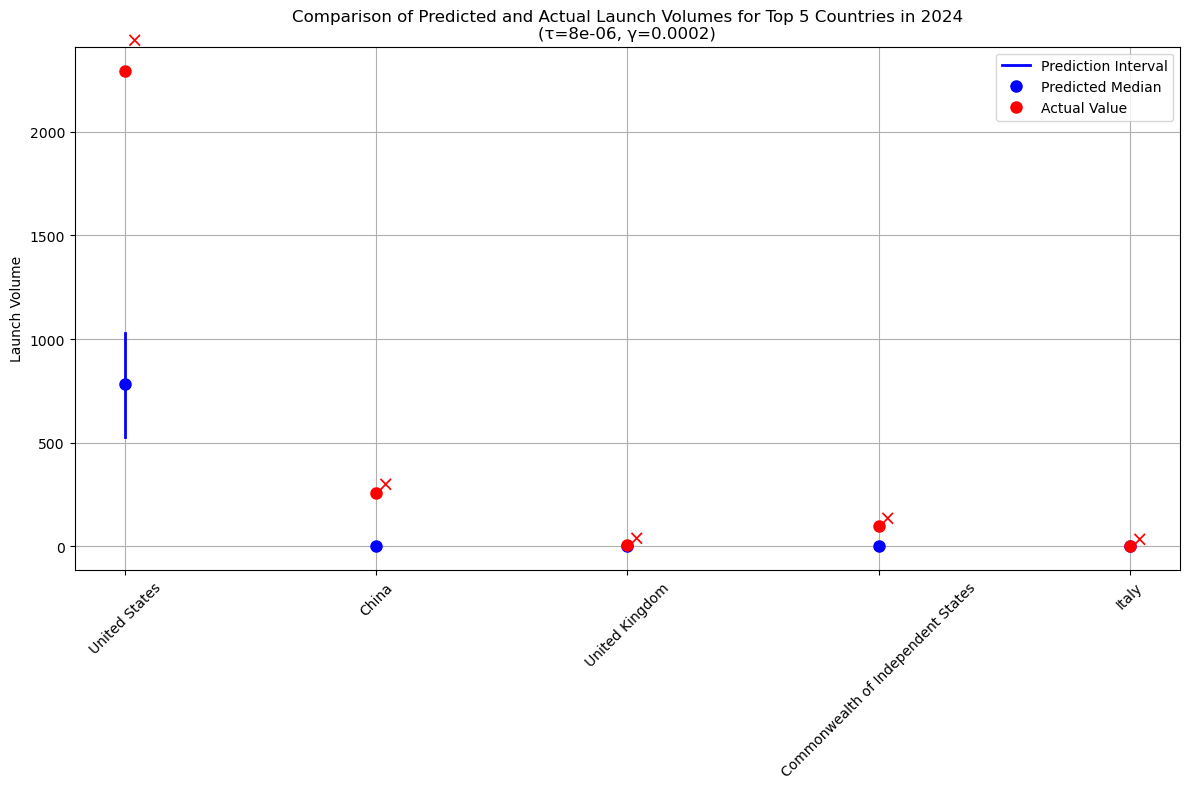

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
# 设置全局字体，确保支持英文
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# 定义输出目录
output_dir = "D:/Academic/RUC/Zheng/太空经济/CongestionTax/data/results/"

# 加载原始数据和ARIMA预测结果
df = pd.read_csv(f"{output_dir}major_player_data.csv")
arima_predictions = pd.read_csv(f"{output_dir}arima_predictions_2024.csv")

# 使用您提供的正确税率参数
tau = 0.000008  # 正确的tau值
gamma = 0.0002  # 正确的gamma值

# 创建一个新的DataFrame来存储2024年的预测发射量
pred_2024 = pd.DataFrame(columns=['country', 'flow_launch_pred_lower', 'flow_launch_pred_median', 
                                 'flow_launch_pred_upper', 'flow_launch_actual'])

# 获取2023年的总发射量数据（用作St-1）
df_2023 = df[df['year'] == 2023]
S_prev = df_2023['annual_launch_total'].sum() if len(df_2023) > 0 else 0

# 确保我们有2024年的数据
df_2024 = df[df['year'] == 2024]
if len(df_2024) == 0:
    print("Warning: No 2024 data found in major_player_data")
else:
    print(f"Found {len(df_2024)} records for year 2024")

# 找出发射量前五的国家（基于2023年数据）
top5_countries = df_2023.sort_values('flow_launch', ascending=False)['country'].unique()[:5]
if len(top5_countries) < 5:  # 如果2023年数据不足5个国家
    # 使用所有年份数据
    top5_countries = df.groupby('country')['flow_launch'].sum().sort_values(ascending=False).index[:5]

print(f"Top 5 countries by launch volume: {list(top5_countries)}")

# 为每个预测情景(lower, median, upper)计算所有国家的发射量
for scenario in ['lower', 'median', 'upper']:
    # 创建临时数据框存储计算中间结果
    temp_data = pd.DataFrame(columns=['country', 'c_pred', 'd', 'lambda'])
    
    # 首先计算每个国家的d值和lambda值
    for country in arima_predictions['country'].unique():
        # 获取该国家的成本预测数据
        country_pred = arima_predictions[arima_predictions['country'] == country]
        
        if len(country_pred) == 0:
            continue
        
        # 使用固定的gamma值 - 不再从数据中获取
        # 获取预测的成本值
        c_pred = country_pred[f'c_pred_{scenario}'].iloc[0]
        
        # 计算d值 - 使用固定的tau和gamma
        d = 1 / (tau + gamma)
        
        # 添加到临时数据框
        new_row = {
            'country': country,
            'c_pred': c_pred,
            'd': d
        }
        temp_data = pd.concat([temp_data, pd.DataFrame([new_row])], ignore_index=True)
    
    # 计算lambda值
    sum_d = temp_data['d'].sum()
    temp_data['lambda'] = temp_data['d'] / (1/tau + sum_d)
    
    # 计算lambda*c的总和
    sum_lambda_c = (temp_data['lambda'] * temp_data['c_pred']).sum()
    
    # 计算每个国家的发射量
    for country in temp_data['country']:
        row = temp_data[temp_data['country'] == country].iloc[0]
        d = row['d']
        c_pred = row['c_pred']
        
        # 使用公式: xit = dit[(1 - τSt-1 - cit) - Σj∈N λjt(1 - τSt-1 - cjt)]
        sum_lambda = temp_data['lambda'].sum()
        flow_launch_pred = d * ((1 - tau * S_prev) * (1 - sum_lambda) - c_pred + sum_lambda_c)
        
        # 确保发射量不为负
        flow_launch_pred = max(0, flow_launch_pred)
        
        # 获取2024年的实际发射量（直接从df中获取）
        country_2024 = df[(df['country'] == country) & (df['year'] == 2024)]
        flow_launch_actual = country_2024['flow_launch'].iloc[0] if len(country_2024) > 0 else None
        
        # 更新预测DataFrame
        if country in pred_2024['country'].values:
            idx = pred_2024[pred_2024['country'] == country].index[0]
            pred_2024.at[idx, f'flow_launch_pred_{scenario}'] = flow_launch_pred
            if flow_launch_actual is not None:  # 只在有实际值时更新
                pred_2024.at[idx, 'flow_launch_actual'] = flow_launch_actual
        else:
            new_row = {
                'country': country,
                f'flow_launch_pred_{scenario}': flow_launch_pred,
                'flow_launch_actual': flow_launch_actual
            }
            pred_2024 = pd.concat([pred_2024, pd.DataFrame([new_row])], ignore_index=True)

# 确保所有国家的实际发射量都已添加
for country in df_2024['country'].unique():
    if country not in pred_2024['country'].values:
        # 获取该国家2024年的实际发射量
        country_data = df_2024[df_2024['country'] == country]
        flow_launch_actual = country_data['flow_launch'].iloc[0] if len(country_data) > 0 else None
        
        if flow_launch_actual is not None:
            new_row = {
                'country': country,
                'flow_launch_actual': flow_launch_actual
            }
            pred_2024 = pd.concat([pred_2024, pd.DataFrame([new_row])], ignore_index=True)

# 整理预测DataFrame，确保所有列都存在
for scenario in ['lower', 'median', 'upper']:
    if f'flow_launch_pred_{scenario}' not in pred_2024.columns:
        pred_2024[f'flow_launch_pred_{scenario}'] = np.nan

# 保存预测结果
pred_2024.to_csv(f'{output_dir}flow_launch_predictions_2024.csv', index=False)
pred_2024.to_csv('flow_launch_predictions_2024.csv', index=False)
print(f"Launch volume predictions for 2024 completed and saved (using tau={tau}, gamma={gamma})")

# 分析前五大国家的预测结果
print("\nComparison of predicted and actual launch volumes for top 5 countries in 2024:")
top5_pred = pred_2024[pred_2024['country'].isin(top5_countries)]
print(top5_pred)

# 检查实际值是否在预测区间内
def check_in_interval(row):
    if pd.isna(row['flow_launch_actual']):
        return 'No actual data'
    elif (pd.isna(row['flow_launch_pred_lower']) or 
          pd.isna(row['flow_launch_pred_upper'])):
        return 'No prediction interval'
    elif (row['flow_launch_actual'] >= row['flow_launch_pred_lower'] and 
          row['flow_launch_actual'] <= row['flow_launch_pred_upper']):
        return 'Within prediction interval'
    else:
        return 'Outside prediction interval'

top5_pred['Prediction Assessment'] = top5_pred.apply(check_in_interval, axis=1)
print("\nPrediction interval assessment results:")
print(top5_pred[['country', 'flow_launch_pred_lower', 'flow_launch_pred_median', 
                'flow_launch_pred_upper', 'flow_launch_actual', 'Prediction Assessment']])

# 可视化前五大国家的预测结果
plt.figure(figsize=(12, 8))
for i, country in enumerate(top5_countries):
    if country in top5_pred['country'].values:
        country_data = top5_pred[top5_pred['country'] == country]
        x = i
        
        # 确保数据存在
        if ('flow_launch_pred_lower' in country_data.columns and 
            'flow_launch_pred_upper' in country_data.columns and
            not pd.isna(country_data['flow_launch_pred_lower'].iloc[0]) and
            not pd.isna(country_data['flow_launch_pred_upper'].iloc[0])):
            
            y_lower = country_data['flow_launch_pred_lower'].iloc[0]
            y_median = country_data['flow_launch_pred_median'].iloc[0]
            y_upper = country_data['flow_launch_pred_upper'].iloc[0]
            
            # 绘制预测区间
            plt.plot([x, x], [y_lower, y_upper], 'b-', linewidth=2)
            plt.plot(x, y_median, 'bo', markersize=8)
        
        # 如果有实际值，绘制实际值
        if ('flow_launch_actual' in country_data.columns and 
            not pd.isna(country_data['flow_launch_actual'].iloc[0])):
            
            y_actual = country_data['flow_launch_actual'].iloc[0]
            plt.plot(x, y_actual, 'ro', markersize=8)
            
            # 判断实际值是否在预测区间内
            has_prediction = ('flow_launch_pred_lower' in country_data.columns and 
                             'flow_launch_pred_upper' in country_data.columns and
                             not pd.isna(country_data['flow_launch_pred_lower'].iloc[0]) and
                             not pd.isna(country_data['flow_launch_pred_upper'].iloc[0]))
            
            if has_prediction:
                y_lower = country_data['flow_launch_pred_lower'].iloc[0]
                y_upper = country_data['flow_launch_pred_upper'].iloc[0]
                
                if y_actual >= y_lower and y_actual <= y_upper:
                    plt.text(x, y_actual*1.05, '√', color='green', fontsize=15)
                else:
                    plt.text(x, y_actual*1.05, '×', color='red', fontsize=15)

plt.xticks(range(len(top5_countries)), top5_countries, rotation=45)
plt.ylabel('Launch Volume')
plt.title(f'Comparison of Predicted and Actual Launch Volumes for Top 5 Countries in 2024\n(τ={tau}, γ={gamma})')
plt.legend(['Prediction Interval', 'Predicted Median', 'Actual Value'])
plt.grid(True)
plt.tight_layout()

# 保存图表
plt.savefig(f'{output_dir}flow_launch_predictions_2024.png')
plt.savefig('flow_launch_predictions_2024.png')
print("Prediction chart has been saved")

plt.show()

训练数据形状: (4757, 12)
2024年数据形状: (71, 12)

发射量前五的国家: ['United States', 'China', 'Commonwealth of Independent States', 'France', 'Japan']


c:\Users\Lenovo\anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:975: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\Lenovo\anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:963: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Lenovo\anaconda3\lib\site-packages\statsmodels\base\model.py:567: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warn("Maximum Likelihood optimization failed to converge. "
c:\Users\Lenovo\anaconda3\lib\site-packages\statsmodels\base\model.py:567: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warn("Maximum Likelihood optimization failed to converge. "
c:\Users\Lenovo\anaconda3\lib\site-packages\statsmodels\bas

预测Indonesia时出错: LU decomposition error.
Traceback (most recent call last):
  File "C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18472\2656627573.py", line 110, in <module>
    results = model.fit()
  File "c:\Users\Lenovo\anaconda3\lib\site-packages\statsmodels\tsa\arima\model.py", line 325, in fit
    res = super(ARIMA, self).fit(return_params=return_params,
  File "c:\Users\Lenovo\anaconda3\lib\site-packages\statsmodels\tsa\statespace\mlemodel.py", line 654, in fit
    mlefit = super(MLEModel, self).fit(start_params, method=method,
  File "c:\Users\Lenovo\anaconda3\lib\site-packages\statsmodels\base\model.py", line 518, in fit
    xopt, retvals, optim_settings = optimizer._fit(f, score, start_params,
  File "c:\Users\Lenovo\anaconda3\lib\site-packages\statsmodels\base\optimizer.py", line 215, in _fit
    xopt, retvals = func(objective, gradient, start_params, fargs, kwargs,
  File "c:\Users\Lenovo\anaconda3\lib\site-packages\statsmodels\base\optimizer.py", line 437, in _fit_lbfgs
   

c:\Users\Lenovo\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:213: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  warnings.warn('An unsupported index was provided and will be'
c:\Users\Lenovo\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:213: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  warnings.warn('An unsupported index was provided and will be'
c:\Users\Lenovo\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:213: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  warnings.warn('An unsupported index was provided and will be'
c:\Users\Lenovo\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:213: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  warnings.warn('An unsupported index was provided and will be'
c:\Users\Lenovo\anaconda3\lib\site-packages\stat


预测结果形状: (70, 9)
预测数据中的国家列表: ['Algeria', 'Angola', 'Argentina', 'Australia', 'Bahamas', 'Bangladesh', 'Belgium', 'Bolivia', 'Brazil', 'Bulgaria', 'Canada', 'Chile', 'China', 'Colombia', 'Commonwealth of Independent States', 'Croatia', 'Czech Republic', 'Denmark', 'Ecuador', 'Egypt', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'India', 'Iran', 'Iraq', 'Israel', 'Italy', 'Japan', 'Kenya', 'Kuwait', 'Latvia', 'Lithuania', 'Luxembourg', 'Malaysia', 'Mexico', 'Morocco', 'Netherlands', 'New Zealand', 'North Korea', 'Norway', 'Pakistan', 'Peru', 'Philippines', 'Poland', 'Portugal', 'Qatar', 'Saudi Arabia', 'Singapore', 'Slovakia', 'Slovenia', 'South Africa', 'South Korea', 'Spain', 'Sweden', 'Switzerland', 'Taiwan', 'Thailand', 'Tunisia', 'Turkey', 'Ukraine', 'United Arab Emirates', 'United Kingdom', 'United States', 'Uruguay', 'Venezuela', 'Vietnam']

可用国家的2024年预测结果：

United States:
ARIMA模型阶数: (1, 1, 2)
预测发射量区间: [0.00, 0.00, 0.00]
实际发射量: 2295.00

China:
ARIMA模型阶数: (2, 1, 

c:\Users\Lenovo\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:183: RuntimeWarning: Glyph 24180 missing from current font.
  font.set_text(s, 0, flags=flags)
c:\Users\Lenovo\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:183: RuntimeWarning: Glyph 20027 missing from current font.
  font.set_text(s, 0, flags=flags)
c:\Users\Lenovo\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:183: RuntimeWarning: Glyph 35201 missing from current font.
  font.set_text(s, 0, flags=flags)
c:\Users\Lenovo\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:183: RuntimeWarning: Glyph 39044 missing from current font.
  font.set_text(s, 0, flags=flags)
c:\Users\Lenovo\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:183: RuntimeWarning: Glyph 27979 missing from current font.
  font.set_text(s, 0, flags=flags)
c:\Users\Lenovo\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:183: RuntimeWarning: Glyph 21306 missing from curre

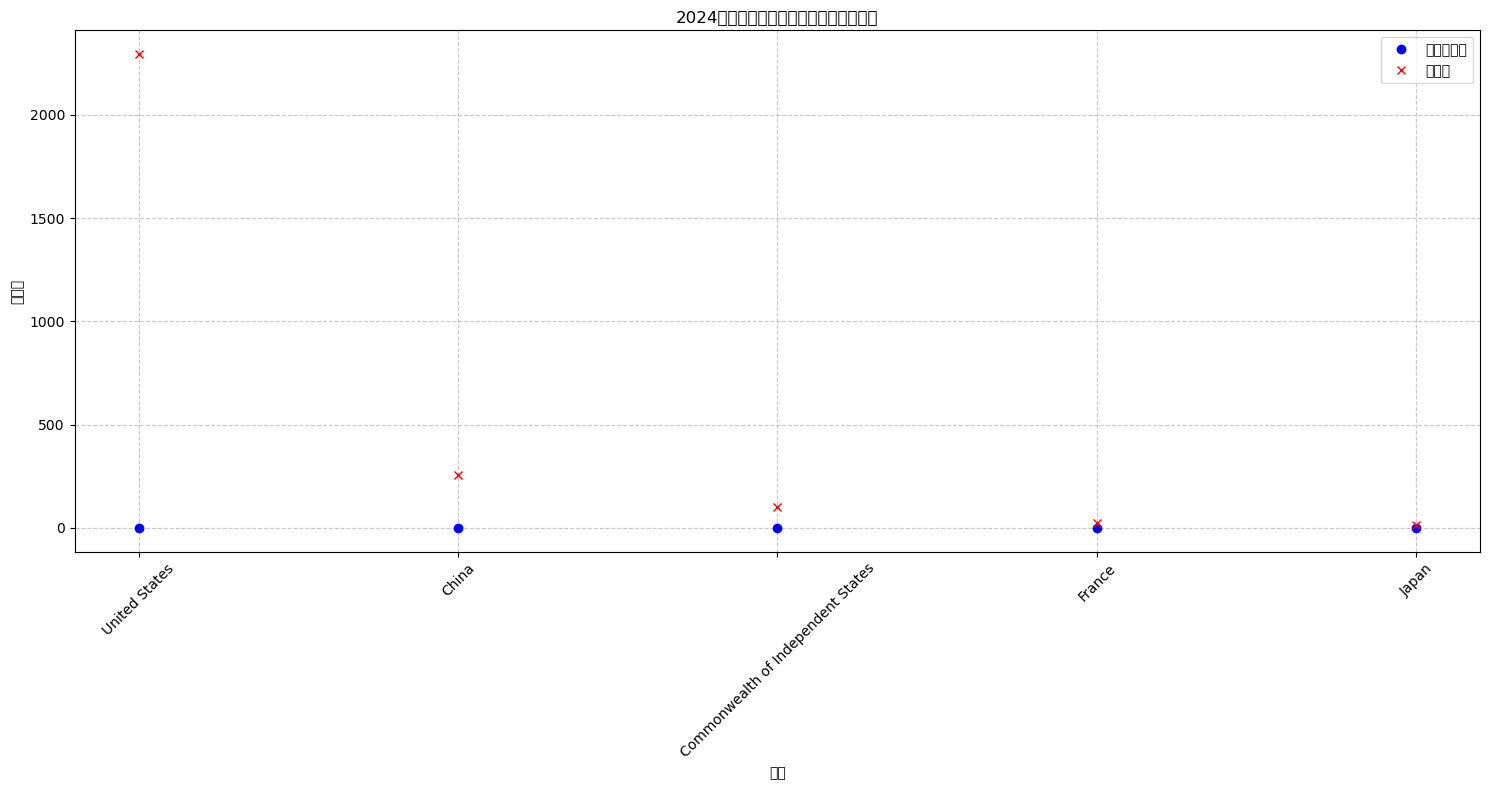

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
import os

# 定义ARIMA模型阶数选择函数
def find_best_arima_order(series, max_p=3, max_d=2, max_q=3):
    """为时间序列找到最优的ARIMA模型阶数"""
    adf_result = adfuller(series)
    d = 1 if adf_result[1] > 0.05 else 0
    
    best_aic = float('inf')
    best_order_aic = None
    
    for p in range(max_p + 1):
        for q in range(max_q + 1):
            try:
                model = ARIMA(series, order=(p, d, q))
                results = model.fit()
                if results.aic < best_aic:
                    best_aic = results.aic
                    best_order_aic = (p, d, q)
            except:
                continue
    
    return best_order_aic if best_order_aic else (1,0,0)

# 在 Monte Carlo 模拟之前定义输出目录
output_dir = "D:/Academic/RUC/Zheng/太空经济/CongestionTax/data/results/"



# 读取数据
df = pd.read_csv(f"{output_dir}major_player_data.csv")

# 分离训练数据和2024年数据
df_train = df[df['year'] <= 2023].copy()
df_2024 = df[df['year'] == 2024].copy()

print("训练数据形状:", df_train.shape)
print("2024年数据形状:", df_2024.shape)

# 找出发射量前五的国家
top5_countries = df_2024.nlargest(5, 'flow_launch')['country'].tolist()
print("\n发射量前五的国家:", top5_countries)

# 创建预测结果DataFrame
predictions = pd.DataFrame(columns=['country', 'year', 'arima_order', 
                                  'c_pred_lower', 'c_pred_median', 'c_pred_upper',
                                  'launch_pred_lower', 'launch_pred_median', 'launch_pred_upper'])


# 加载参数和数据
tau = 0.000008
gamma = 0.0002


# 对每个国家进行预测
for country_name in df_train['country'].unique():
    # 检查这个国家在训练数据中是否有足够的数据点
    country_data = df_train[df_train['country'] == country_name].sort_values('year')
    
    if len(country_data) < 3:  # 至少需要3个数据点才能进行ARIMA
        print(f"国家 {country_name} 数据点不足，跳过")
        continue
    
    try:
        # 确保 c_sim_median 列存在
        if 'c_sim_median' not in country_data.columns:
            print(f"国家 {country_name} 缺少c_sim_median列，正在尝试计算...")
            # 类似于第二个模块中的计算方式
            country_data['c_sim_median'] = country_data['LHS'] - (gamma * country_data['flow_launch'])
        
        # 使用c_sim_median找到最优ARIMA模型
        c_series_median = country_data['c_sim_median']
        
        # 确保数据为数值类型
        c_series_median = pd.to_numeric(c_series_median, errors='coerce')
        
        # 检查数据是否有效
        if c_series_median.isna().any() or len(c_series_median) < 3:
            print(f"国家 {country_name} 的c_sim_median数据无效，跳过")
            continue
            
        best_order = find_best_arima_order(c_series_median)
        
        # 对三个c_sim序列进行预测
        c_forecasts = {}
        for c_type in ['lower', 'median', 'upper']:
            # 确保c_sim列存在
            if f'c_sim_{c_type}' not in country_data.columns:
                if c_type == 'median':
                    country_data[f'c_sim_{c_type}'] = c_series_median
                else:
                    # 可以根据median添加一定偏差来模拟lower和upper
                    delta = 0.01 if c_type == 'upper' else -0.01
                    country_data[f'c_sim_{c_type}'] = c_series_median * (1 + delta)
            
            c_series = country_data[f'c_sim_{c_type}']
            c_series = pd.to_numeric(c_series, errors='coerce')
                
            # 检查数据是否有效
            if c_series.isna().any():
                print(f"国家 {country_name} 的c_sim_{c_type}数据无效，使用median替代")
                c_series = c_series_median
                
            model = ARIMA(c_series, order=best_order)
            results = model.fit()
            
            # 修复forecast索引问题 - 以下是修改部分
            forecast = results.forecast(steps=1)
            
            # 处理不同类型的forecast结果
            if isinstance(forecast, pd.Series):
                # 如果是Series，使用第一个元素，不管索引是什么
                forecast_value = forecast.iloc[0]
            elif isinstance(forecast, np.ndarray):
                # 如果是numpy数组，使用第一个元素
                forecast_value = forecast[0]
            else:
                # 如果是其他类型，尝试直接使用
                forecast_value = forecast
                
            c_forecasts[c_type] = max(forecast_value, 1e-10)  # 防止负值
        
        # 明确定义tau和gamma值
        tau = 8e-06  # 使用第二个模块中的值
        gamma = 0.0002  # 使用第二个模块中的值
        
        # 获取2023年的数据用于计算2024年的预测发射量
        try:
            prev_total_launch = df_train[df_train['year'] == 2023]['X_total_cum'].sum()
            annual_total_2023 = df_train[df_train['year'] == 2023]['flow_launch'].sum()
        except Exception as e:
            print(f"获取2023年数据出错: {e}")
            # 使用备用方法
            prev_total_launch = country_data[country_data['year'] == country_data['year'].max()]['X_total_cum'].sum()
            annual_total_2023 = country_data[country_data['year'] == country_data['year'].max()]['flow_launch'].sum()
        
        # 计算预测发射量
        launch_preds = {}
        for c_type in ['lower', 'median', 'upper']:
            launch_preds[c_type] = max(
                (1 - tau * prev_total_launch - tau * annual_total_2023 - c_forecasts[c_type]) / (tau + gamma),
                0
            )
        
        # 创建单个国家的预测结果
        new_row = pd.DataFrame({
            'country': [country_name],
            'year': [2024],
            'arima_order': [str(best_order)],
            'c_pred_lower': [c_forecasts['lower']],
            'c_pred_median': [c_forecasts['median']],
            'c_pred_upper': [c_forecasts['upper']],
            'launch_pred_lower': [launch_preds['lower']],
            'launch_pred_median': [launch_preds['median']],
            'launch_pred_upper': [launch_preds['upper']]
        })
        
        # 使用concat而不是直接赋值
        predictions = pd.concat([predictions, new_row], ignore_index=True)
        
    except Exception as e:
        print(f"预测{country_name}时出错: {e}")
        import traceback
        print(traceback.format_exc())  # 打印详细错误信息
        continue

print("\n预测结果形状:", predictions.shape)
print("预测数据中的国家列表:", predictions['country'].unique().tolist())

# 合并实际2024年数据
predictions = predictions.merge(
    df_2024[['country', 'flow_launch']],
    on='country',
    how='left'
)

# 检查前五国家是否都在预测结果中
available_countries = []
for country in top5_countries:
    if country in predictions['country'].values:
        available_countries.append(country)
    else:
        print(f"警告: {country} 不在预测结果中")

if not available_countries:
    print("错误: 没有一个前五国家在预测结果中!")
    # 创建一个简单图表表示错误
    plt.figure(figsize=(10, 6))
    plt.text(0.5, 0.5, "无法生成预测图表: 预测数据不包含任何前五发射国",
             horizontalalignment='center', verticalalignment='center', fontsize=14)
    plt.axis('off')
    plt.savefig(f"{output_dir}prediction_error.png", dpi=300)
    plt.show()
else:
    # 输出可用国家的预测结果
    print("\n可用国家的2024年预测结果：")
    for country in available_countries:
        pred = predictions[predictions['country'] == country].iloc[0]
        print(f"\n{country}:")
        print(f"ARIMA模型阶数: {pred['arima_order']}")
        print(f"预测发射量区间: [{pred['launch_pred_lower']:.2f}, {pred['launch_pred_median']:.2f}, {pred['launch_pred_upper']:.2f}]")
        print(f"实际发射量: {pred['flow_launch']:.2f}")

    # 绘制可用国家的预测区间图
    plt.figure(figsize=(15, 8))

    x = np.arange(len(available_countries))

    for i, country in enumerate(available_countries):
        pred = predictions[predictions['country'] == country].iloc[0]
        
        # 绘制预测区间
        plt.vlines(x=i, ymin=pred['launch_pred_lower'], ymax=pred['launch_pred_upper'], 
                  color='blue', alpha=0.3)
        # 绘制中位数点
        plt.plot(i, pred['launch_pred_median'], 'bo', label='预测中位数' if i == 0 else '')
        # 绘制实际值
        plt.plot(i, pred['flow_launch'], 'rx', label='实际值' if i == 0 else '')

    plt.xlabel('国家')
    plt.ylabel('发射量')
    plt.title('2024年主要发射国预测区间与实际值对比')
    plt.xticks(x, available_countries, rotation=45)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()

    # 保存图表
    plt.savefig(f"{output_dir}available_countries_prediction_2024.png", dpi=300, bbox_inches='tight')
    plt.show()

# 保存预测结果
predictions.to_csv(f"{output_dir}predictions_2024.csv", index=False)

In [ ]:
def find_best_arima_order(series, max_p=3, max_d=2, max_q=3):
    """
    为时间序列找到最优的ARIMA模型阶数
    """
    # ADF检验
    adf_result = adfuller(series)
    d = 1 if adf_result[1] > 0.05 else 0
    
    # 尝试不同的p,d,q组合
    best_aic = float('inf')
    best_order_aic = None
    
    for p in range(max_p + 1):
        for q in range(max_q + 1):
            try:
                model = ARIMA(series, order=(p, d, q))
                results = model.fit()
                if results.aic < best_aic:
                    best_aic = results.aic
                    best_order_aic = (p, d, q)
            except:
                continue
    
    return best_order_aic

def forecast_analysis(launched_data):
    """
    修改后的预测分析函数
    """
    current_year = launched_data['year'].max()
    years_to_2050 = 2050 - current_year
    predictions = pd.DataFrame()
    arima_orders = {}  # 用于存储每个国家的ARIMA阶数
    
    for country in launched_data['country'].unique():
        country_data = launched_data[launched_data['country'] == country]
        
        try:
            c_series = country_data['c_sim']
            
            
            if len(c_series) > 5:
                order = find_best_arima_order(c_series)
            else:
                order = (1,0,0)
            
            arima_orders[country] = order  # 记录ARIMA阶数
            
            model = ARIMA(c_series, order=order)
            results = model.fit()
            c_forecast = results.forecast(steps=years_to_2050)
            c_forecast = np.maximum(c_forecast, 1e-10)
            
            country_predictions = pd.DataFrame({
                'year': range(current_year + 1, 2051),
                'country': [country] * years_to_2050,
                'c_pred': c_forecast,
                'arima_order': [str(order)] * years_to_2050
            })
            
            
            predictions = pd.concat([predictions, country_predictions])
            
        except Exception as e:
            print(f"预测{country}时出错: {str(e)}")
            continue
    
    # 在最后统一输出每个国家使用的ARIMA阶数
    print("\n各国使用的ARIMA模型阶数:")
    for country, order in arima_orders.items():
        print(f"{country}: ARIMA{order}")
    
    return predictions

In [ ]:
# 5. 可视化函数
def plot_results(df, predictions):
    # 创建画布
    plt.figure(figsize=(15, 15))
    
    # c值预测趋势
    plt.subplot(3, 1, 1)
    for country in predictions['country'].unique():
        country_pred = predictions[predictions['country'] == country]
        plt.plot(country_pred['year'], country_pred['c_pred'], alpha=0.5, label=country)
    plt.title('Predicted c-values Trend (2023-2050)')
    plt.xlabel('Year')
    plt.ylabel('c-value')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    

    # c值在2035和2050年的分布
    plt.subplot(3, 1, 3)
    years_to_plot = [2035, 2050]
    c_data = [predictions[predictions['year'] == year]['c_pred'] for year in years_to_plot]
    plt.boxplot(c_data, labels=['2035', '2050'])
    plt.title('Distribution of c-values in 2035 and 2050')
    plt.ylabel('c-value')
    
    plt.tight_layout()
    plt.show()

# 主函数
def main():
    try:
        print("Using existing processed data")
        
        # 3. 模拟分析
        df_sim, launched_data, non_launched_data = simulation_analysis(df)
        print("Simulation analysis completed")
        
        # 4. 预测分析
        predictions = forecast_analysis(launched_data)
        print("Forecast analysis completed")
        
        # 5. 输出结果
        print("\nPrediction Summary:")
        print("\nYear 2035:")
        pred_2035 = predictions[predictions['year'] == 2035]
        print("\nc-value statistics:")
        print(pred_2035['c_pred'].describe())
      
        
        print("\nYear 2050:")
        pred_2050 = predictions[predictions['year'] == 2050]
        print("\nc-value statistics:")
        print(pred_2050['c_pred'].describe())
 
        
        # 6. 可视化结果
        plot_results(df_sim, predictions)
        
        # 7. 保存结果到CSV文件
        df_sim.to_csv('simulation_results.csv', index=False)
        predictions.to_csv('predictions_results.csv', index=False)
        
        # 8. 输出详细数据
        print("\n模拟结果数据预览（前5行）：")
        print(df_sim.head())
        print("\n预测结果数据预览（前5行）：")
        print(predictions.head())
        
        # 9. 输出基本统计信息
        print("\n模拟结果基本统计：")
        print(df_sim.describe())
        print("\n预测结果基本统计：")
        print(predictions.describe())
        
        return df_sim, predictions
        
    except Exception as e:
        print(f"An error occurred: {str(e)}")
        return None, None

# 运行分析a
df_result, predictions = main()

In [ ]:
# 在main()运行之后添加以下代码

def calculate_equilibrium_parameters(countries, tau=0.000008, gamma=0.0002):
    """
    计算均衡所需的固定参数
    """
    # 计算每个国家的αi（由于gamma固定，所有国家的αi相同）
    alpha = 1 / (tau + gamma)
    alphas = {country: alpha for country in countries}
    
    # 计算分母项 1/τ + Σαj
    n = len(countries)
    denominator = (1/tau) + (n * alpha)
    
    # 计算每个国家的λi（由于alpha相同，所有国家的λi也相同）
    lambda_i = alpha / denominator
    lambdas = {country: lambda_i for country in countries}
    
    print(f"\n参数计算过程:")
    print(f"tau = {tau}, gamma = {gamma}")
    print(f"alpha = 1/({tau} + {gamma}) = {alpha}")
    print(f"国家数量 n = {n}")
    print(f"分母 = 1/{tau} + {n} * {alpha} = {denominator}")
    print(f"lambda = {alpha} / {denominator} = {lambda_i}")
    
    return alphas, lambdas

def calculate_launches(predictions, alphas, lambdas, df, tau=0.000008):
    """
    根据预测的c值计算每个国家的发射量
    xit = αit[(1-cit) - Σj∈N λjt(1-cjt) - τSt-1]
    """
    new_predictions = predictions.copy()
    new_predictions['theoretical_flow_launch'] = 0.0
    new_predictions['sum_lambda_c'] = 0.0
    
    # 获取最后一年的prev_total_launch作为初始St-1
    last_year_data = df[df['year'] == df['year'].max()]
    prev_total_launch = 18004.742
    
    for year in sorted(new_predictions['year'].unique()):
        year_data = new_predictions[new_predictions['year'] == year]
        
        # 计算当年的Σλj(1-cj)
        sum_lambda_c = 0
        for _, row in year_data.iterrows():
            country = row['country']
            c_j = row['c_pred']
            term = lambdas[country] * (1 - c_j)
            sum_lambda_c += term
        
        # 将sum_lambda_c值添加到该年份的所有行
        new_predictions.loc[new_predictions['year'] == year, 'sum_lambda_c'] = sum_lambda_c
        
        # 计算每个国家的发射量
        total_launches = 0
        for country in year_data['country'].unique():
            country_mask = (new_predictions['year'] == year) & (new_predictions['country'] == country)
            c_i = new_predictions.loc[country_mask, 'c_pred'].iloc[0]
            # 加入τSt-1项
            x_i = alphas[country] * ((1 - c_i) - sum_lambda_c - tau * prev_total_launch)
            x_i = max(x_i, 0)
            new_predictions.loc[country_mask, 'theoretical_flow_launch'] = x_i
            total_launches += x_i
        
        # 更新St-1为当年的总发射量，用于下一年的计算
        prev_total_launch += total_launches
        
        # 添加当年的total_launch到预测结果中
        new_predictions.loc[new_predictions['year'] == year, 'total_launch_t_minus_1'] = prev_total_launch
    
    return new_predictions

# 主要计算过程
countries = predictions['country'].unique()
print(f"\n总计{len(countries)}个国家参与计算")

# 计算均衡参数
alphas, lambdas = calculate_equilibrium_parameters(countries)

# 保存alpha和lambda值
alpha_lambda_df = pd.DataFrame({
    'country': list(alphas.keys()),
    'alpha': list(alphas.values()),
    'lambda': list(lambdas.values())
})
alpha_lambda_df.to_csv('alpha_lambda_values.csv', index=False)
print("\nAlpha和Lambda值已保存到 'alpha_lambda_values.csv'")

# 计算发射量
new_predictions = calculate_launches(predictions, alphas, lambdas, df)
# 输出结果统计
print("\n基于理论公式的发射量预测统计:")
print("\n2035年:")
pred_2035 = new_predictions[new_predictions['year'] == 2035]
print(pred_2035[['country', 'c_pred', 'theoretical_flow_launch']].to_string())

print("\n2050年:")
pred_2050 = new_predictions[new_predictions['year'] == 2050]
print(pred_2050[['country', 'c_pred', 'theoretical_flow_launch']].to_string())

# 保存新的预测结果
new_predictions.to_csv('theoretical_predictions_results.csv', index=False)
print("\n新的预测结果已保存到 'theoretical_predictions_results.csv'")

In [ ]:
# 导入基础数据
df = pd.read_csv('simulation_results.csv')

# 删除指定的列
columns_to_drop = ['c_hat', 'gamma_hat', 'gamma_hat_constrained', 
                   'c_hat_constrained', 'LHS_pred']
df = df.drop(columns=columns_to_drop)

# 计算每年的cost_global（基于flow_launch=0的样本）
cost_global_by_year = df[df['flow_launch'] == 0].groupby('year')['c_sim'].first()

# 为每个样本添加对应年份的cost_global
df['cost_global'] = df['year'].map(cost_global_by_year)

# 生成launch_status变量
df['launch_status'] = (df['flow_launch'] > 0).astype(int)

# 保存新的数据集
df.to_csv('simulation_latestlaunch.csv', index=False)

# 输出处理结果摘要
print("数据处理完成：")
print(f"总样本数: {len(df)}")
print("\n前5行数据预览：")
print(df.head())
print("\n每年的cost_global值：")
print(cost_global_by_year)
print("\nlaunch_status的分布：")
print(df['launch_status'].value_counts())

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate launch frequency between 2015-2024
launch_freq = df[
    (df['year'] >= 2015) & 
    (df['year'] <= 2024)
].groupby('country')['launch_status'].sum().reset_index()
launch_freq.columns = ['country', 'frequency_launch']

# Merge frequency info with 2024 data
df_2024 = df[df['year'] == 2024].copy()
df_2024 = df_2024.merge(launch_freq, on='country', how='left')

# Create figure
plt.figure(figsize=(15, 6))

# Subplot 1: Distribution for all countries
plt.subplot(1, 2, 1)
plt.hist(df_2024['frequency_launch'], bins=20, edgecolor='black')
plt.title('Launch Frequency Distribution - All Countries (2015-2024)')
plt.xlabel('Launch Frequency')
plt.ylabel('Number of Countries')

# Add descriptive statistics
stats_all = df_2024['frequency_launch'].describe()
plt.text(0.7, 0.95, 
         f'Mean: {stats_all["mean"]:.2f}\nStd: {stats_all["std"]:.2f}\n' + 
         f'Min: {stats_all["min"]:.0f}\nMax: {stats_all["max"]:.0f}\n' +
         f'Total Countries: {len(df_2024)}',
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.8))

# Subplot 2: Distribution for active countries only
df_2024_active = df_2024[df_2024['frequency_launch'] > 0]
plt.subplot(1, 2, 2)
plt.hist(df_2024_active['frequency_launch'], bins=20, edgecolor='black')
plt.title('Launch Frequency Distribution - Active Countries (2015-2024)')
plt.xlabel('Launch Frequency')
plt.ylabel('Number of Countries')

# Add descriptive statistics
stats_active = df_2024_active['frequency_launch'].describe()
plt.text(0.7, 0.95, 
         f'Mean: {stats_active["mean"]:.2f}\nStd: {stats_active["std"]:.2f}\n' + 
         f'Min: {stats_active["min"]:.0f}\nMax: {stats_active["max"]:.0f}\n' +
         f'Total Countries: {len(df_2024_active)}',
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Print detailed statistics
print("\nLaunch Frequency Statistics - All Countries:")
print(stats_all)
print("\nLaunch Frequency Statistics - Active Countries:")
print(stats_active)

# Save frequency data
launch_freq.to_csv('launch_frequency_2015_2024.csv', index=False)
print("\nLaunch frequency data saved to 'launch_frequency_2015_2024.csv'")

# Print top 10 most active countries
print("\nTop 10 Countries by Launch Frequency:")
print(launch_freq.nlargest(10, 'frequency_launch'))

In [ ]:
# 筛选发射频率大于等于5的国家
major_players = launch_freq[launch_freq['frequency_launch'] >= 5]

# 打印主要参与者信息
print("Major Players (Launch Frequency >= 5):")
print(f"Total number of major players: {len(major_players)}")
print("\nDetailed list of major players:")
print(major_players.sort_values('frequency_launch', ascending=False))

# 使用这些主要参与者筛选原始数据
major_players_list = major_players['country'].tolist()
df_major = df[df['country'].isin(major_players_list)].copy()

# 打印数据集信息
print(f"\nOriginal dataset size: {len(df)}")
print(f"Major players dataset size: {len(df_major)}")
print(f"Percentage of data retained: {(len(df_major)/len(df)*100):.2f}%")

# 保存主要参与者名单
major_players.to_csv('major_players_list.csv', index=False)
print("\nMajor players list saved to 'major_players_list.csv'")

# 保存主要参与者的完整数据
df_major.to_csv('major_players_data.csv', index=False)
print("Major players complete data saved to 'major_players_data.csv'")

# 显示每个主要参与者的发射频率分布
plt.figure(figsize=(12, 6))
plt.bar(range(len(major_players)), major_players['frequency_launch'])
plt.xticks(range(len(major_players)), major_players['country'], rotation=45, ha='right')
plt.title('Launch Frequency Distribution Among Major Players (2015-2024)')
plt.xlabel('Country')
plt.ylabel('Launch Frequency')
plt.tight_layout()
plt.show()

In [ ]:
# 读取major players数据
df_major = pd.read_csv('major_players_data.csv')

def simulation_analysis_major(df):
    """
    针对主要参与者的模拟分析函数
    """
    # 创建新的预测结果列
    df['gamma_fixed'] = 0.00001  # 固定gamma值
    df['c_sim'] = df['LHS'] - (0.00001 * df['flow_launch'])
    df['LHS_pred'] = df['c_sim'] + (0.00001 * df['flow_launch'])
    
    return df

def forecast_analysis_major(df):
    """
    针对主要参与者的预测分析函数
    """
    current_year = df['year'].max()
    years_to_2050 = 2050 - current_year
    predictions = pd.DataFrame()
    arima_orders = {}  # 用于存储每个国家的ARIMA阶数
    
    for country in df['country'].unique():
        country_data = df[df['country'] == country]
        
        try:
            c_series = country_data['c_sim']
            
            if len(c_series) > 5:
                order = find_best_arima_order(c_series)
            else:
                order = (1,0,0)
            
            arima_orders[country] = order
            
            model = ARIMA(c_series, order=order)
            results = model.fit()
            c_forecast = results.forecast(steps=years_to_2050)
            c_forecast = np.maximum(c_forecast, 1e-10)
            
            country_predictions = pd.DataFrame({
                'year': range(current_year + 1, 2051),
                'country': country,
                'c_pred': c_forecast,
                'arima_order': str(order)
            })
            
            last_lhs = country_data['LHS'].iloc[-1]
            country_predictions['flow_launch_pred'] = np.maximum(
                (last_lhs - country_predictions['c_pred']) / 0.00001, 
                0
            )
            
            predictions = pd.concat([predictions, country_predictions])
            
        except Exception as e:
            print(f"预测{country}时出错: {str(e)}")
            continue
    
    print("\n主要参与者的ARIMA模型阶数:")
    for country, order in arima_orders.items():
        print(f"{country}: ARIMA{order}")
    
    return predictions

def main_major_players():
    try:
        print("使用主要参与者数据进行分析")
        
        # 模拟分析
        df_sim = simulation_analysis_major(df_major)
        print("主要参与者模拟分析完成")
        
        # 预测分析
        predictions = forecast_analysis_major(df_sim)
        print("主要参与者预测分析完成")
        
        # 输出结果
        print("\n预测结果摘要:")
        print("\n2035年:")
        pred_2035 = predictions[predictions['year'] == 2035]
        print("\nc值统计:")
        print(pred_2035['c_pred'].describe())
        print("\n发射量统计:")
        print(pred_2035['flow_launch_pred'].describe())
        
        print("\n2050年:")
        pred_2050 = predictions[predictions['year'] == 2050]
        print("\nc值统计:")
        print(pred_2050['c_pred'].describe())
        print("\n发射量统计:")
        print(pred_2050['flow_launch_pred'].describe())
        
        # 可视化结果
        plot_results(df_sim, predictions)
        
        # 保存结果
        df_sim.to_csv('major_players_simulation_results.csv', index=False)
        predictions.to_csv('major_players_predictions_results.csv', index=False)
        
        print("\n结果已保存到 'major_players_simulation_results.csv' 和 'major_players_predictions_results.csv'")
        
        return df_sim, predictions
        
    except Exception as e:
        print(f"发生错误: {str(e)}")
        return None, None

# 运行主要参与者分析
df_major_result, major_predictions = main_major_players()

In [ ]:
# 使用major_players的预测结果进行均衡计算

# 读取预测数据
major_predictions = pd.read_csv('major_players_predictions_results.csv')

# 计算主要参与者的均衡参数
major_countries = major_predictions['country'].unique()
print(f"\n总计{len(major_countries)}个主要参与国家参与计算")

# 计算均衡参数 (使用相同的tau和gamma值)
major_alphas, major_lambdas = calculate_equilibrium_parameters(major_countries, tau=0.0000062, gamma=0.00001)

# 保存主要参与者的alpha和lambda值
major_alpha_lambda_df = pd.DataFrame({
    'country': list(major_alphas.keys()),
    'alpha': list(major_alphas.values()),
    'lambda': list(major_lambdas.values())
})
major_alpha_lambda_df.to_csv('major_players_alpha_lambda_values.csv', index=False)
print("\n主要参与者的Alpha和Lambda值已保存到 'major_players_alpha_lambda_values.csv'")

# 计算主要参与者的理论发射量
major_theoretical_predictions = calculate_launches(major_predictions, major_alphas, major_lambdas, df)

# 输出主要参与者的结果统计
print("\n主要参与者基于理论公式的发射量预测统计:")
print("\n2035年:")
major_pred_2035 = major_theoretical_predictions[major_theoretical_predictions['year'] == 2035]
print(major_pred_2035[['country', 'c_pred', 'theoretical_flow_launch']].to_string())

print("\n2050年:")
major_pred_2050 = major_theoretical_predictions[major_theoretical_predictions['year'] == 2050]
print(major_pred_2050[['country', 'c_pred', 'theoretical_flow_launch']].to_string())

# 保存主要参与者的新预测结果
major_theoretical_predictions.to_csv('major_players_theoretical_predictions_results.csv', index=False)
print("\n主要参与者的新预测结果已保存到 'major_players_theoretical_predictions_results.csv'")

# 添加结果比较
print("\n预测结果比较分析:")
for year in [2035, 2050]:
    year_data = major_theoretical_predictions[major_theoretical_predictions['year'] == year]
    print(f"\n{year}年预测统计:")
    print("\n原始预测发射量统计:")
    print(year_data['flow_launch_pred'].describe())
    print("\n理论模型发射量统计:")
    print(year_data['theoretical_flow_launch'].describe())

In [ ]:
# ... existing code ...

# 模型准确性测试：对比2024年预测值与实际值
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
import os
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# 自定义MAPE函数（因为sklearn版本较旧）
def mean_absolute_percentage_error(y_true, y_pred):
    """
    计算平均绝对百分比误差
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # 避免除以零
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# 创建结果目录
results_dir = "model_accuracy_test_2024"
if not os.path.exists(results_dir):
    os.makedirs(results_dir)

# 读取原始数据
df_original = pd.read_csv('major_players_data.csv')

# 2024年的实际累计发射量
X_total_cum_2024 = 20807.979

# 设置要测试的gamma和tau组合
gamma_values = [0.0002]
tau_values = [8e-06]

param_combinations = [(g, t) for g in gamma_values for t in tau_values]

# 定义ARIMA模型阶数选择函数
def find_best_arima_order(series, max_p=3, max_d=2, max_q=3):
    """为时间序列找到最优的ARIMA模型阶数"""
    adf_result = adfuller(series)
    d = 1 if adf_result[1] > 0.05 else 0
    
    best_aic = float('inf')
    best_order_aic = None
    
    for p in range(max_p + 1):
        for q in range(max_q + 1):
            try:
                model = ARIMA(series, order=(p, d, q))
                results = model.fit()
                if results.aic < best_aic:
                    best_aic = results.aic
                    best_order_aic = (p, d, q)
            except:
                continue
    
    return best_order_aic if best_order_aic else (1,0,0)

# 筛选2023年及之前的数据
df_train = df_original[df_original['year'] <= 2023].copy()
df_2024 = df_original[df_original['year'] == 2024].copy()

# 存储所有预测结果的DataFrame
all_predictions = pd.DataFrame()

# 方法1：使用ARIMA模型和不同的gamma/tau组合
for gamma, tau in param_combinations:
    print(f"\n测试方法1: ARIMA模型 (gamma={gamma}, tau={tau})")
    
    # 计算c_sim
    df_train['gamma_test'] = gamma
    df_train['tau_test'] = tau
    df_train['c_sim'] = df_train['LHS'] - (gamma * df_train['flow_launch'])
    
    # 基于c_sim进行ARIMA预测
    predictions = pd.DataFrame()
    
    for country in df_train['country'].unique():
        country_data = df_train[df_train['country'] == country]
        
        try:
            c_series = country_data['c_sim']
            
            if len(c_series) > 5:
                order = find_best_arima_order(c_series)
            else:
                order = (1,0,0)
            
            model = ARIMA(c_series, order=order)
            results = model.fit()
            c_forecast = results.forecast(steps=1)  # 预测2024
            c_forecast = np.maximum(c_forecast, 1e-10)  # 防止负值
            
            country_predictions = pd.DataFrame({
                'year': [2024],
                'country': country,
                'c_pred': c_forecast,
                'arima_order': str(order),
                'method': f'ARIMA',
                'gamma': gamma,
                'tau': tau,
                'param_combo': f'g{gamma}_t{tau}'
            })
            
            last_lhs = country_data['LHS'].iloc[-1]
            country_predictions['flow_launch_pred'] = np.maximum(
                (last_lhs - country_predictions['c_pred']) / gamma, 
                0
            )
            
            predictions = pd.concat([predictions, country_predictions])
            
        except Exception as e:
            print(f"预测{country}时出错: {str(e)}")
            continue
    
    # 计算均衡发射量
    countries = predictions['country'].unique()
    
    # 计算alpha和lambda值
    alphas = {}
    lambdas = {}
    
    for country in countries:
        alphas[country] = 1 / (tau + gamma)
    
    alpha_sum = sum(alphas.values())
    
    for country in countries:
        lambdas[country] = alphas[country] / ((1/tau) + alpha_sum)
    
    # 计算发射量
    predictions['theoretical_flow_launch'] = 0.0
    predictions['sum_lambda_c'] = 0.0
    
    # 获取2023年的total_launch作为初始St-1
    prev_total_launch = df_train[df_train['year'] == 2023]['flow_launch'].sum()
    
    for year in sorted(predictions['year'].unique()):
        year_data = predictions[predictions['year'] == year]
        
        # 计算当年的Σλj(1-cj)
        sum_lambda_c = 0
        for _, row in year_data.iterrows():
            country = row['country']
            c_j = row['c_pred']
            term = lambdas[country] * (1 - c_j)
            sum_lambda_c += term
        
        predictions.loc[predictions['year'] == year, 'sum_lambda_c'] = sum_lambda_c
        
        total_launches = 0
        
        for country in year_data['country'].unique():
            country_mask = (predictions['year'] == year) & (predictions['country'] == country)
            c_i = predictions.loc[country_mask, 'c_pred'].iloc[0]
            
            x_i = alphas[country] * ((1 - c_i) - sum_lambda_c - tau * prev_total_launch)
            x_i = max(x_i, 0)
            
            predictions.loc[country_mask, 'theoretical_flow_launch'] = x_i
            total_launches += x_i
        
        prev_total_launch += total_launches
        predictions.loc[predictions['year'] == year, 'total_launch_t_minus_1'] = prev_total_launch
    
    # 将结果添加到总预测结果中
    all_predictions = pd.concat([all_predictions, predictions])

# 方法2：使用c_sim增长率的线性模型
for gamma, tau in param_combinations:
    print(f"\n测试方法2: c_sim增长率线性模型 (gamma={gamma}, tau={tau})")
    
    # 计算c_sim
    df_train['gamma_test'] = gamma
    df_train['tau_test'] = tau
    df_train['c_sim'] = df_train['LHS'] - (gamma * df_train['flow_launch'])
    
    # 使用c_sim增长率进行预测
    growth_predictions = pd.DataFrame()
    
    for country in df_train['country'].unique():
        country_data = df_train[df_train['country'] == country].sort_values('year')
        
        try:
            # 计算c_sim的年增长率
            country_data['c_sim_growth'] = country_data['c_sim'].pct_change()
            
            # 去除NaN值
            growth_data = country_data.dropna(subset=['c_sim_growth'])
            
            if len(growth_data) > 1:  # 至少需要两个增长率点进行线性回归
                # 准备线性回归数据
                X = growth_data['year'].values.reshape(-1, 1)
                y = growth_data['c_sim_growth'].values
                
                model = LinearRegression()
                model.fit(X, y)
                
                # 预测2024年的增长率
                growth_forecast = model.predict(np.array([[2024]]))
                
                # 获取最后一年的c_sim值
                last_c_sim = country_data['c_sim'].iloc[-1]
                last_year = country_data['year'].iloc[-1]
                
                # 使用预测的增长率计算2024年的c_sim
                c_forecast = last_c_sim * (1 + growth_forecast[0])
                c_forecast = np.maximum(c_forecast, 1e-10)  # 防止负值
                
                country_predictions = pd.DataFrame({
                    'year': [2024],
                    'country': country,
                    'c_pred': c_forecast,
                    'method': 'Growth_Rate',
                    'gamma': gamma,
                    'tau': tau,
                    'param_combo': f'g{gamma}_t{tau}'
                })
                
                last_lhs = country_data['LHS'].iloc[-1]
                country_predictions['flow_launch_pred'] = np.maximum(
                    (last_lhs - country_predictions['c_pred']) / gamma, 
                    0
                )
                
                growth_predictions = pd.concat([growth_predictions, country_predictions])
                
            else:
                # 如果数据不足，使用最后一年的c_sim值
                last_c_sim = country_data['c_sim'].iloc[-1]
                
                country_predictions = pd.DataFrame({
                    'year': [2024],
                    'country': country,
                    'c_pred': last_c_sim,
                    'method': 'Growth_Rate',
                    'gamma': gamma,
                    'tau': tau,
                    'param_combo': f'g{gamma}_t{tau}'
                })
                
                last_lhs = country_data['LHS'].iloc[-1]
                country_predictions['flow_launch_pred'] = np.maximum(
                    (last_lhs - country_predictions['c_pred']) / gamma, 
                    0
                )
                
                growth_predictions = pd.concat([growth_predictions, country_predictions])
                
        except Exception as e:
            print(f"预测{country}时出错: {str(e)}")
            continue
    
    # 计算均衡发射量（与ARIMA方法相同的逻辑）
    countries = growth_predictions['country'].unique()
    
    # 计算alpha和lambda值
    alphas = {}
    lambdas = {}
    
    for country in countries:
        alphas[country] = 1 / (tau + gamma)
    
    alpha_sum = sum(alphas.values())
    
    for country in countries:
        lambdas[country] = alphas[country] / ((1/tau) + alpha_sum)
    
    # 计算发射量
    growth_predictions['theoretical_flow_launch'] = 0.0
    growth_predictions['sum_lambda_c'] = 0.0
    
    # 获取2023年的total_launch作为初始St-1
    prev_total_launch = df_train[df_train['year'] == 2023]['flow_launch'].sum()
    
    for year in sorted(growth_predictions['year'].unique()):
        year_data = growth_predictions[growth_predictions['year'] == year]
        
        # 计算当年的Σλj(1-cj)
        sum_lambda_c = 0
        for _, row in year_data.iterrows():
            country = row['country']
            c_j = row['c_pred']
            term = lambdas[country] * (1 - c_j)
            sum_lambda_c += term
        
        growth_predictions.loc[growth_predictions['year'] == year, 'sum_lambda_c'] = sum_lambda_c
        
        total_launches = 0
        
        for country in year_data['country'].unique():
            country_mask = (growth_predictions['year'] == year) & (growth_predictions['country'] == country)
            c_i = growth_predictions.loc[country_mask, 'c_pred'].iloc[0]
            
            x_i = alphas[country] * ((1 - c_i) - sum_lambda_c - tau * prev_total_launch)
            x_i = max(x_i, 0)
            
            growth_predictions.loc[country_mask, 'theoretical_flow_launch'] = x_i
            total_launches += x_i
        
        prev_total_launch += total_launches
        growth_predictions.loc[growth_predictions['year'] == year, 'total_launch_t_minus_1'] = prev_total_launch
    
    # 将结果添加到总预测结果中
    all_predictions = pd.concat([all_predictions, growth_predictions])

# 方法3：使用c_sim的线性回归模型
for gamma, tau in param_combinations:
    print(f"\n测试方法3: c_sim线性回归模型 (gamma={gamma}, tau={tau})")
    
    # 计算c_sim
    df_train['gamma_test'] = gamma
    df_train['tau_test'] = tau
    df_train['c_sim'] = df_train['LHS'] - (gamma * df_train['flow_launch'])
    
    # 使用线性回归预测c_sim
    linear_predictions = pd.DataFrame()
    
    for country in df_train['country'].unique():
        country_data = df_train[df_train['country'] == country]
        
        try:
            # 准备线性回归数据
            X = country_data['year'].values.reshape(-1, 1)
            y = country_data['c_sim'].values
            
            if len(y) > 1:  # 至少需要两个点进行线性回归
                model = LinearRegression()
                model.fit(X, y)
                
                # 预测2024年
                c_forecast = model.predict(np.array([[2024]]))
                c_forecast = np.maximum(c_forecast, 1e-10)  # 防止负值
                
                country_predictions = pd.DataFrame({
                    'year': [2024],
                    'country': country,
                    'c_pred': c_forecast[0],
                    'method': 'Linear_Regression',
                    'gamma': gamma,
                    'tau': tau,
                    'param_combo': f'g{gamma}_t{tau}'
                })
                
                last_lhs = country_data['LHS'].iloc[-1]
                country_predictions['flow_launch_pred'] = np.maximum(
                    (last_lhs - country_predictions['c_pred']) / gamma, 
                    0
                )
                
                linear_predictions = pd.concat([linear_predictions, country_predictions])
                
            else:
                print(f"{country}数据不足，无法进行线性回归")
                
        except Exception as e:
            print(f"预测{country}时出错: {str(e)}")
            continue
    
    # 计算均衡发射量（与ARIMA方法相同的逻辑）
    countries = linear_predictions['country'].unique()
    
    # 计算alpha和lambda值
    alphas = {}
    lambdas = {}
    
    for country in countries:
        alphas[country] = 1 / (tau + gamma)
    
    alpha_sum = sum(alphas.values())
    
    for country in countries:
        lambdas[country] = alphas[country] / ((1/tau) + alpha_sum)
    
    # 计算发射量
    linear_predictions['theoretical_flow_launch'] = 0.0
    linear_predictions['sum_lambda_c'] = 0.0
    
    # 获取2023年的total_launch作为初始St-1
    prev_total_launch = df_train[df_train['year'] == 2023]['flow_launch'].sum()
    
    for year in sorted(linear_predictions['year'].unique()):
        year_data = linear_predictions[linear_predictions['year'] == year]
        
        # 计算当年的Σλj(1-cj)
        sum_lambda_c = 0
        for _, row in year_data.iterrows():
            country = row['country']
            c_j = row['c_pred']
            term = lambdas[country] * (1 - c_j)
            sum_lambda_c += term
        
        linear_predictions.loc[linear_predictions['year'] == year, 'sum_lambda_c'] = sum_lambda_c
        
        total_launches = 0
        
        for country in year_data['country'].unique():
            country_mask = (linear_predictions['year'] == year) & (linear_predictions['country'] == country)
            c_i = linear_predictions.loc[country_mask, 'c_pred'].iloc[0]
            
            x_i = alphas[country] * ((1 - c_i) - sum_lambda_c - tau * prev_total_launch)
            x_i = max(x_i, 0)
            
            linear_predictions.loc[country_mask, 'theoretical_flow_launch'] = x_i
            total_launches += x_i
        
        prev_total_launch += total_launches
        linear_predictions.loc[linear_predictions['year'] == year, 'total_launch_t_minus_1'] = prev_total_launch
    
    # 将线性回归结果添加到总预测结果中
    all_predictions = pd.concat([all_predictions, linear_predictions])

# 保存所有预测结果
all_predictions.to_csv(f"{results_dir}/all_predictions.csv", index=False)

# 对比2024年预测与实际值
predictions_2024 = all_predictions[all_predictions['year'] == 2024].copy()

# 合并实际2024年数据
actual_2024 = df_2024[['country', 'flow_launch']].rename(columns={'flow_launch': 'actual_flow_launch'})
comparison = pd.merge(predictions_2024, actual_2024, on='country', how='left')

# 计算差异
comparison['absolute_diff'] = abs(comparison['theoretical_flow_launch'] - comparison['actual_flow_launch'])
# 使用自定义函数计算百分比差异，避免除以零的问题
comparison['percentage_diff'] = 100 * comparison['absolute_diff'] / comparison['actual_flow_launch'].clip(lower=0.1)

# 保存比较结果
comparison.to_csv(f"{results_dir}/prediction_vs_actual_2024.csv", index=False)

# 计算每种方法和参数组合的总发射量
total_launches = comparison.groupby(['method', 'gamma', 'tau', 'param_combo']).agg({
    'theoretical_flow_launch': 'sum',
    'actual_flow_launch': 'sum',
    'absolute_diff': 'mean',
    'percentage_diff': 'mean'
}).reset_index()

# 计算总体实际发射量
actual_total = df_2024['flow_launch'].sum()
total_launches['actual_total'] = actual_total

# 保存总发射量结果
total_launches.to_csv(f"{results_dir}/total_launches_comparison.csv", index=False)

# 重点关注中国、美国和CIS的结果
focus_countries = ['China', 'United States', 'Commonwealth of Independent States']
focus_results = comparison[comparison['country'].isin(focus_countries)].copy()
focus_results = focus_results.sort_values(['country', 'method', 'gamma', 'tau'])
focus_results.to_csv(f"{results_dir}/focus_countries_comparison.csv", index=False)

# 打印重点国家的结果
print("\n重点国家预测结果对比:")
for country in focus_countries:
    print(f"\n{country}的预测结果:")
    country_data = focus_results[focus_results['country'] == country]
    for _, row in country_data.iterrows():
        print(f"方法: {row['method']}, gamma: {row['gamma']}, tau: {row['tau']}")
        print(f"  预测发射量: {row['theoretical_flow_launch']:.2f}")
        print(f"  实际发射量: {row['actual_flow_launch']:.2f}")
        print(f"  绝对差异: {row['absolute_diff']:.2f}")
        print(f"  百分比差异: {row['percentage_diff']:.2f}%")

# 创建可视化图表
# 1. 按照参数组合绘制总发射量对比图
methods = total_launches['method'].unique()

# 为每个方法创建一个图表，x轴为参数组合，y轴为发射量
for method in methods:
    method_data = total_launches[total_launches['method'] == method].sort_values(['gamma', 'tau'])
    
    plt.figure(figsize=(15, 8))
    
    # 绘制预测值
    plt.plot(method_data['param_combo'], method_data['theoretical_flow_launch'], 'o-', label='预测总发射量')
    
    # 绘制实际值（水平线）
    plt.axhline(y=actual_total, color='r', linestyle='-', label='实际总发射量')
    
    plt.xlabel('参数组合 (gamma_tau)')
    plt.ylabel('发射量')
    plt.title(f'{method} 方法下不同参数组合的2024年总发射量预测')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{results_dir}/{method}_total_prediction.png", dpi=300)
    plt.close()

# 2. 为重点国家创建参数敏感性分析图
for country in focus_countries:
    for method in methods:
        country_method_data = focus_results[(focus_results['country'] == country) & 
                                           (focus_results['method'] == method)].sort_values(['gamma', 'tau'])
        
        if not country_method_data.empty:
            plt.figure(figsize=(15, 8))
            
            # 绘制预测值
            plt.plot(country_method_data['param_combo'], country_method_data['theoretical_flow_launch'], 'o-', label='预测发射量')
            
            # 绘制实际值（水平线）
            actual_value = country_method_data['actual_flow_launch'].iloc[0]
            plt.axhline(y=actual_value, color='r', linestyle='-', label='实际发射量')
            
            plt.xlabel('参数组合 (gamma_tau)')
            plt.ylabel('发射量')
            plt.title(f'{country} - {method} 方法下不同参数组合的2024年发射量预测')
            plt.xticks(rotation=45)
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.savefig(f"{results_dir}/{country}_{method}_prediction.png", dpi=300)
            plt.close()

# 3. 创建gamma和tau的热力图，展示预测准确性
for method in methods:
    method_data = total_launches[total_launches['method'] == method].copy()
    
    # 创建gamma和tau的网格
    gamma_unique = sorted(method_data['gamma'].unique())
    tau_unique = sorted(method_data['tau'].unique())
    
    # 创建热力图数据
    heatmap_data = np.zeros((len(gamma_unique), len(tau_unique)))
    
    for i, gamma in enumerate(gamma_unique):
        for j, tau in enumerate(tau_unique):
            mask = (method_data['gamma'] == gamma) & (method_data['tau'] == tau)
            if mask.any():
                # 使用绝对差异作为热力图值
                heatmap_data[i, j] = method_data.loc[mask, 'absolute_diff'].values[0]
    
    plt.figure(figsize=(10, 8))
    plt.imshow(heatmap_data, cmap='viridis_r')  # viridis_r使得较低的误差显示为较亮的颜色
    
    # 添加坐标轴标签
    plt.xticks(np.arange(len(tau_unique)), [f"{t:.1e}" for t in tau_unique], rotation=45)
    plt.yticks(np.arange(len(gamma_unique)), [f"{g:.4f}" for g in gamma_unique])
    
    plt.xlabel('tau值')
    plt.ylabel('gamma值')
    plt.title(f'{method} 方法下不同参数组合的预测误差热力图')
    
    plt.colorbar(label='平均绝对误差')
    plt.tight_layout()
    plt.savefig(f"{results_dir}/{method}_error_heatmap.png", dpi=300)
    plt.close()

# 4. 创建一个综合图表，比较三种方法在最佳参数组合下的表现
best_params = total_launches.groupby('method').apply(
    lambda x: x.loc[x['absolute_diff'].idxmin()]
).reset_index(drop=True)

plt.figure(figsize=(12, 8))

x = np.arange(len(methods))
width = 0.35

plt.bar(x - width/2, best_params['theoretical_flow_launch'], width, label='最佳参数下的预测值')
plt.bar(x + width/2, best_params['actual_total'], width, label='实际值')

plt.xlabel('预测方法')
plt.ylabel('总发射量')
plt.title('各方法在最佳参数组合下的2024年总发射量预测')
plt.xticks(x, methods)
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()
plt.savefig(f"{results_dir}/best_methods_comparison.png", dpi=300)
plt.close()

print(f"\n所有结果已保存到 {results_dir} 目录")

In [ ]:
# 基于蒙特卡洛方法计算c_sim_opt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm

# 创建结果目录
results_dir = "monte_carlo_results"
if not os.path.exists(results_dir):
    os.makedirs(results_dir)

# 读取数据
df = pd.read_csv("major_players_data.csv")

# 设置参数
gamma = 0.0002
tau = 8e-06
n_simulations = 100  # 蒙特卡洛模拟次数

# 设置随机种子以确保结果可重现
np.random.seed(42)

# 分离出2024年的数据
df_2024 = df[df['year'] == 2024].copy()
df_historical = df[df['year'] < 2024].copy()

# 获取所有国家和年份
countries = df_historical['country'].unique()
years = sorted(df_historical['year'].unique())

# 创建一个字典来存储每个国家每年的c_sim_opt结果
c_sim_opt_results = {country: {year: [] for year in years} for country in countries}

# 计算alpha和lambda值
alphas = {}
lambdas = {}

for country in countries:
    alphas[country] = 1 / (tau + gamma)

alpha_sum = sum(alphas.values())

for country in countries:
    lambdas[country] = alphas[country] / ((1/tau) + alpha_sum)

print("开始蒙特卡洛模拟...")

# 执行蒙特卡洛模拟
for sim in tqdm(range(n_simulations)):
    # 为每次模拟创建一个临时数据框
    df_sim = df_historical.copy()
    
    # 为每个观测到的发射量生成理论最优发射量（X_bar）
    # X_bar在(0.9X, 1.1X)之间随机取值
    df_sim['theoretical_optimal_launch'] = df_sim.apply(
        lambda row: row['flow_launch'] * np.random.uniform(0.9, 1.1),
        axis=1
    )
    
    # 按年份排序处理数据
    df_sim = df_sim.sort_values(by=['year', 'country'])
    
    # 对每年的数据进行处理
    prev_total_launch = 0  # 初始化前一年的总发射量
    
    for year in years:
        year_data = df_sim[df_sim['year'] == year]
        
        # 初始化当年的sum_lambda_c
        sum_lambda_c = 0
        
        # 第一轮计算，使用初始猜测的c值
        for country in countries:
            if country in year_data['country'].values:
                country_mask = (df_sim['year'] == year) & (df_sim['country'] == country)
                
                # 使用上一年的c值作为初始猜测，如果没有则使用0.5
                if year > min(years) and country in df_sim[(df_sim['year'] == year-1)]['country'].values:
                    prev_c = df_sim[(df_sim['year'] == year-1) & (df_sim['country'] == country)]['c_sim_opt'].iloc[0] \
                        if 'c_sim_opt' in df_sim.columns else 0.5
                else:
                    prev_c = 0.5
                
                df_sim.loc[country_mask, 'c_sim_opt'] = prev_c
                
                # 更新sum_lambda_c
                sum_lambda_c += lambdas[country] * (1 - prev_c)
        
        # 迭代求解直到收敛
        max_iterations = 50
        tolerance = 1e-6
        converged = False
        
        for iteration in range(max_iterations):
            old_c_values = df_sim[df_sim['year'] == year]['c_sim_opt'].copy()
            old_sum_lambda_c = sum_lambda_c
            
            # 重新计算sum_lambda_c
            sum_lambda_c = 0
            
            for country in countries:
                if country in year_data['country'].values:
                    country_mask = (df_sim['year'] == year) & (df_sim['country'] == country)
                    target_launch = df_sim.loc[country_mask, 'theoretical_optimal_launch'].iloc[0]
                    
                    # 二分法查找合适的c值
                    c_min, c_max = 0, 1
                    c_mid = df_sim.loc[country_mask, 'c_sim_opt'].iloc[0]  # 使用当前值作为初始猜测
                    inner_iterations = 0
                    inner_max_iterations = 100
                    
                    while inner_iterations < inner_max_iterations:
                        # 计算理论发射量
                        term = (1 - c_mid) - sum_lambda_c - tau * prev_total_launch
                        calculated_launch = alphas[country] * term if term > 0 else 0
                        
                        error = calculated_launch - target_launch
                        
                        if abs(error) < tolerance:
                            break
                        
                        if error > 0:  # 计算值太大，需要增加c（减少发射）
                            c_min = c_mid
                        else:  # 计算值太小，需要减少c（增加发射）
                            c_max = c_mid
                        
                        c_mid = (c_min + c_max) / 2
                        inner_iterations += 1
                    
                    # 更新c_sim_opt
                    df_sim.loc[country_mask, 'c_sim_opt'] = c_mid
                    
                    # 更新sum_lambda_c
                    sum_lambda_c += lambdas[country] * (1 - c_mid)
            
            # 检查是否收敛
            new_c_values = df_sim[df_sim['year'] == year]['c_sim_opt']
            if np.max(np.abs(new_c_values - old_c_values)) < tolerance and abs(sum_lambda_c - old_sum_lambda_c) < tolerance:
                converged = True
                break
        
        if not converged:
            print(f"警告：第{year}年的求解未收敛")
        
        # 计算当年的总发射量
        total_launches = 0
        for country in countries:
            if country in year_data['country'].values:
                country_mask = (df_sim['year'] == year) & (df_sim['country'] == country)
                c_i = df_sim.loc[country_mask, 'c_sim_opt'].iloc[0]
                
                term = (1 - c_i) - sum_lambda_c - tau * prev_total_launch
                x_i = alphas[country] * term if term > 0 else 0
                
                # 更新理论发射量（这应该接近我们的目标值）
                df_sim.loc[country_mask, 'calculated_launch'] = x_i
                
                total_launches += x_i
        
        # 更新前一年的总发射量
        prev_total_launch = total_launches
    
    # 收集每个国家每年的c_sim_opt结果
    for country in countries:
        for year in years:
            country_year_data = df_sim[(df_sim['year'] == year) & (df_sim['country'] == country)]
            if not country_year_data.empty and 'c_sim_opt' in country_year_data.columns:
                c_sim_opt_results[country][year].append(country_year_data['c_sim_opt'].iloc[0])

print("蒙特卡洛模拟完成！")

# 计算每个国家每年c_sim_opt的统计数据
c_sim_opt_stats = {country: {year: {} for year in years} for country in countries}

for country in countries:
    for year in years:
        values = c_sim_opt_results[country][year]
        if values:  # 确保有值
            c_sim_opt_stats[country][year] = {
                'median': np.median(values),
                'lower': np.percentile(values, 5),   # 下限（5%分位数）
                'upper': np.percentile(values, 95)   # 上限（95%分位数）
            }

# 将结果保存为CSV
stats_df = []
for country in countries:
    for year in years:
        if c_sim_opt_results[country][year]:  # 确保有值
            stats_df.append({
                'country': country,
                'year': year,
                'c_sim_opt_median': c_sim_opt_stats[country][year]['median'],
                'c_sim_opt_lower': c_sim_opt_stats[country][year]['lower'],
                'c_sim_opt_upper': c_sim_opt_stats[country][year]['upper']
            })

stats_df = pd.DataFrame(stats_df)
stats_df.to_csv(f"{results_dir}/c_sim_opt_statistics.csv", index=False)

print(f"统计结果已保存到 {results_dir}/c_sim_opt_statistics.csv")

# 为每个国家绘制c_sim_opt的时间序列图
main_countries = ['China', 'United States', 'Commonwealth of Independent States']  # 主要关注的国家
all_countries = sorted(countries)

# 首先绘制主要国家的图
for country in main_countries:
    if country in all_countries:
        years_with_data = [year for year in years if c_sim_opt_results[country][year]]
        
        if years_with_data:  # 确保有数据
            medians = [c_sim_opt_stats[country][year]['median'] for year in years_with_data]
            lowers = [c_sim_opt_stats[country][year]['lower'] for year in years_with_data]
            uppers = [c_sim_opt_stats[country][year]['upper'] for year in years_with_data]
            
            plt.figure(figsize=(12, 6))
            
            # 绘制中位数线
            plt.plot(years_with_data, medians, 'o-', color='blue', label='中位数')
            
            # 绘制区间
            plt.fill_between(years_with_data, lowers, uppers, color='lightblue', alpha=0.5, label='5%-95%置信区间')
            
            plt.title(f'{country}的c_sim_opt值随时间变化 (gamma={gamma}, tau={tau})')
            plt.xlabel('年份')
            plt.ylabel('c_sim_opt值')
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.legend()
            
            # 添加一些美化元素
            plt.xticks(years_with_data)
            plt.ylim(0, min(1, max(uppers) * 1.1))  # 设置y轴范围
            
            plt.tight_layout()
            plt.savefig(f"{results_dir}/{country}_c_sim_opt_time_series.png", dpi=300)
            plt.close()

# 然后绘制所有国家的组合图
plt.figure(figsize=(15, 10))

for country in all_countries:
    years_with_data = [year for year in years if c_sim_opt_results[country][year]]
    
    if years_with_data:  # 确保有数据
        medians = [c_sim_opt_stats[country][year]['median'] for year in years_with_data]
        
        # 为主要国家使用实线，其他国家使用虚线
        if country in main_countries:
            plt.plot(years_with_data, medians, 'o-', linewidth=2, label=country)
        else:
            plt.plot(years_with_data, medians, '--', alpha=0.5, label=country)

plt.title(f'所有国家的c_sim_opt中位数值随时间变化 (gamma={gamma}, tau={tau})')
plt.xlabel('年份')
plt.ylabel('c_sim_opt中位数值')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xticks(years)
plt.ylim(0, 1)

plt.tight_layout()
plt.savefig(f"{results_dir}/all_countries_c_sim_opt_median.png", dpi=300)
plt.close()

print(f"所有图表已保存到 {results_dir} 目录")

# 计算模型拟合度
# 比较原始发射量和理论最优发射量的差异
fit_stats = []

for sim in range(n_simulations):
    total_squared_error = 0
    total_variance = 0
    n_points = 0
    
    for country in countries:
        for year in years:
            if c_sim_opt_results[country][year]:
                # 查找原始数据中的实际发射量
                actual_data = df_historical[(df_historical['year'] == year) & 
                                           (df_historical['country'] == country)]
                
                if not actual_data.empty:
                    actual_launch = actual_data['flow_launch'].iloc[0]
                    # 理论发射量是在模拟中计算的，这里我们需要重新计算一下
                    c_opt = c_sim_opt_results[country][year][sim]
                    
                    # 为了简化，我们假设其他参数（sum_lambda_c和prev_total_launch）是已知的
                    # 在实际中，这些值应该从该模拟中获取
                    # 这里只是一个近似计算
                    term = (1 - c_opt)  # 忽略了sum_lambda_c和prev_total_launch的影响
                    theoretical_launch = alphas[country] * term if term > 0 else 0
                    
                    # 计算误差
                    error = theoretical_launch - actual_launch
                    total_squared_error += error ** 2
                    
                    # 计算方差
                    total_variance += (actual_launch - df_historical['flow_launch'].mean()) ** 2
                    
                    n_points += 1
    
    if n_points > 0 and total_variance > 0:
        r_squared = 1 - (total_squared_error / total_variance)
        fit_stats.append(r_squared)

# 计算拟合度统计
if fit_stats:
    median_r_squared = np.median(fit_stats)
    lower_r_squared = np.percentile(fit_stats, 5)
    upper_r_squared = np.percentile(fit_stats, 95)
    
    print(f"\n模型拟合度（R²）统计:")
    print(f"中位数 R²: {median_r_squared:.4f}")
    print(f"5%分位数 R²: {lower_r_squared:.4f}")
    print(f"95%分位数 R²: {upper_r_squared:.4f}")

In [ ]:
import pandas as pd
import os
import glob

def combine_csv_data():
    # Get list of all CSV files matching the pattern
    csv_files = glob.glob('consistent_gamma_*_predictions.csv')
    
    # Sort the files to maintain order
    csv_files.sort()
    
    # Initialize an empty DataFrame to store the combined data
    combined_data = pd.DataFrame()
    
    for file in csv_files:
        # Extract gamma value from filename
        gamma_value = file.split('_')[2]
        
        # Read the CSV file
        df = pd.read_csv(file)
        
        # Extract required columns and rename them to include gamma value
        columns_to_extract = {
            'c_pred': f'c_pred_{gamma_value}',
            'theoretical_flow_launch': f'theoretical_flow_launch_{gamma_value}',
     
        }
        
        # If this is the first file, keep year and country columns for reference
        if combined_data.empty:
            extracted_df = df[['year', 'country'] + list(columns_to_extract.keys())].copy()
            extracted_df.rename(columns=columns_to_extract, inplace=True)
            combined_data = extracted_df
        else:
            # For subsequent files, just extract the required columns
            temp_df = df[list(columns_to_extract.keys())].copy()
            temp_df.rename(columns=columns_to_extract, inplace=True)
            
            # Add these columns to combined_data
            combined_data = pd.concat([combined_data, temp_df], axis=1)
    
    # Save the combined data to a new CSV file
    output_file = 'combined_gamma_predictions.csv'
    combined_data.to_csv(output_file, index=False)
    print(f"Combined data saved to {output_file}")
    return combined_data

if __name__ == "__main__":
    combine_csv_data()

In [ ]:
# 反向计算一致的gamma值
def find_consistent_gamma_for_target(df, target_country='United States', target_year=2025, 
                                   target_launch=2500, tau=0.0000062):
    """
    反向计算一个一致的gamma值，使目标国家在目标年份达到指定发射量
    使用同一个gamma值计算c_sim，预测c_pred，并计算发射量
    """
    # 获取所有国家列表
    all_countries = df['country'].unique()
    n = len(all_countries)
    
    # 获取最后一年
    last_year = df['year'].max()
    forecast_steps = target_year - last_year
    
    # 初始累积发射量
    prev_total_launch = 18004.742
    
    print(f"\n反向计算一致的gamma值使{target_country}在{target_year}年达到{target_launch}发射量")
    print(f"国家数量: {n}")
    print(f"当前年份: {last_year}, 预测步数: {forecast_steps}")
    print(f"初始累积发射量: {prev_total_launch}")
    
    # 尝试不同的gamma值
    gamma_values = np.logspace(-6, -2, 50)  # 50个点
    results = []
    
    for gamma in gamma_values:
        try:
            print(f"测试 gamma = {gamma:.6f}")
            
            # 1. 使用当前gamma计算所有国家的c_sim
            df_temp = df.copy()
            df_temp['c_sim'] = df_temp['LHS'] - (gamma * df_temp['flow_launch'])
            
            # 2. 为所有国家预测c_pred
            predictions = pd.DataFrame(columns=['country', 'c_pred'])
            
            for country in all_countries:
                country_data = df_temp[df_temp['country'] == country]
                
                if len(country_data) < 5:  # 数据不足
                    last_c = country_data['c_sim'].iloc[-1] if len(country_data) > 0 else 0.5
                    predictions = predictions.append({'country': country, 'c_pred': last_c}, ignore_index=True)
                    continue
                
                # 使用ARIMA(1,1,1)模型
                try:
                    series = country_data['c_sim']
                    model = ARIMA(series, order=(1,1,1))
                    results_arima = model.fit()
                    forecast = results_arima.forecast(steps=forecast_steps)
                    c_pred = forecast[forecast_steps-1]
                    predictions = predictions.append({'country': country, 'c_pred': c_pred}, ignore_index=True)
                except:
                    # 如果ARIMA模型失败，使用最后的c值
                    last_c = country_data['c_sim'].iloc[-1]
                    predictions = predictions.append({'country': country, 'c_pred': last_c}, ignore_index=True)
            
            # 3. 计算2025年的sum_lambda_c
            alpha = 1 / (tau + gamma)
            lambda_val = alpha / ((1/tau) + (n * alpha))
            
            sum_lambda_c = 0
            for _, row in predictions.iterrows():
                c_j = row['c_pred']
                term = lambda_val * (1 - c_j)
                sum_lambda_c += term
            
            # 4. 计算目标国家的发射量
            target_c = predictions[predictions['country'] == target_country]['c_pred'].values[0]
            
            x_target = alpha * ((1 - target_c) - sum_lambda_c - tau * prev_total_launch)
            x_target = max(x_target, 0)
            
            # 5. 记录结果
            diff = abs(x_target - target_launch)
            results.append({
                'gamma': gamma,
                'c_target': target_c,
                'sum_lambda_c': sum_lambda_c,
                'x_target': x_target,
                'diff': diff
            })
            
            print(f"  c_target: {target_c:.4f}, x_target: {x_target:.2f}, diff: {diff:.2f}")
            
        except Exception as e:
            print(f"  gamma={gamma}时出错: {str(e)}")
            continue
    
    # 找出最佳结果
    if not results:
        print("未找到有效结果")
        return 0.0001
    
    # 转换为DataFrame并按差距排序
    results_df = pd.DataFrame(results)
    best_result = results_df.loc[results_df['diff'].idxmin()]
    
    best_gamma = best_result['gamma']
    best_c = best_result['c_target']
    best_x = best_result['x_target']
    best_diff = best_result['diff']
    
    print(f"\n最佳gamma值: {best_gamma}")
    print(f"{target_country}的c值: {best_c}")
    print(f"使用此gamma计算的发射量: {best_x}")
    print(f"与目标值的差距: {best_diff}")
    
    return best_gamma

# 调用函数
best_gamma = find_consistent_gamma_for_target(df, target_country='United States', 
                                            target_year=2025, target_launch=2500)